In [1]:
import numpy as np
import pandas as pd
import fastf1 as ff1


ff1.Cache.enable_cache('./cache')
ff1.set_log_level('ERROR')
ff1.Cache.offline_mode(True)

### TEST FF1

In [42]:
s1 = ff1.get_session(2019, 'monza', 'R')
s1.load(telemetry=True, laps=True, weather=True)

In [48]:
s1.laps.pick_laps(20)[['LapNumber', 'Driver', 'Position']]

,LapNumber,Driver,Position
19,20.0,GAS,14.0
71,20.0,PER,9.0
133,20.0,LEC,15.0
185,20.0,STR,10.0
237,20.0,VAN,16.0
289,20.0,MAG,18.0
341,20.0,HUL,13.0
394,20.0,RIC,12.0
418,20.0,OCO,6.0
471,20.0,VER,3.0


In [49]:
telemtry = s1.laps.pick_laps(20).pick_drivers("HAM").telemetry
telemtry['DistanceToDriverAheadSeconds'] = telemtry["DistanceToDriverAhead"] / telemtry['Speed']

In [50]:
telemtry['DistanceToDriverAheadSeconds'].mean()

np.float64(0.2676198384400497)

In [4]:
s1_df = pd.DataFrame(s1.laps)

___

In [5]:
s1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 927 entries, 0 to 926
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                927 non-null    timedelta64[ns]
 1   Driver              927 non-null    object         
 2   DriverNumber        927 non-null    object         
 3   LapTime             925 non-null    timedelta64[ns]
 4   LapNumber           927 non-null    float64        
 5   Stint               907 non-null    float64        
 6   PitOutTime          21 non-null     timedelta64[ns]
 7   PitInTime           22 non-null     timedelta64[ns]
 8   Sector1Time         906 non-null    timedelta64[ns]
 9   Sector2Time         925 non-null    timedelta64[ns]
 10  Sector3Time         925 non-null    timedelta64[ns]
 11  Sector1SessionTime  905 non-null    timedelta64[ns]
 12  Sector2SessionTime  925 non-null    timedelta64[ns]
 13  Sector3SessionTime  925 non-null   

In [3]:
s1_df = pd.DataFrame(s1.laps)
s1_df['Compound'].unique()

array(['MEDIUM', 'SOFT', 'HARD'], dtype=object)

### DATA PREPARATION

In [2]:
def load_and_clean_race(year, round_id):
    """
    Loads F1 race data and applies initial cleaning filters based on Hearne's methodology.
    """
    print(f"Loading Year: {year}, Round: {round_id}...")

    # 1. Load session data (Laps and Weather)
    try:
        session = ff1.get_session(year, round_id, 'R')
        # Non serve la telemetria pesante, basta laps=True!
        session.load(laps=True, weather=True)
        laps = session.laps
    except Exception as e:
        print(f"Error loading session: {e}")
        return None
    
    # 2. Remove wet races 
    # A wet race is defined as any race where Intermediate or Wet tyres are used.
    if 'INTERMEDIATE' in laps['Compound'].values or 'WET' in laps['Compound'].values:
        print(f"Skipping {year} Round {round_id}: Wet race detected.")
        return None
    
    # 3. Remove laps with LapTime greater than 150,000 milliseconds
    # Convert LapTime (timedelta) to milliseconds for easier filtering
    laps['LapTime_ms'] = laps['LapTime'].dt.total_seconds() * 1000

    # Keep laps under 150000 ms, or laps where LapTime is NaT (e.g., pit out laps sometimes)
    laps = laps[(laps['LapTime_ms'] <= 150000) | (laps['LapTime_ms'].isna())]

    # Creiamo la variabile Target InPits: è True se PitInTime non è nullo
    laps['InPits'] = laps['PitInTime'].notna()

    # 4. Remove drivers on suboptimal strategies based on pitstop counts
    # Count pitstops per driver (using PitInTime as an indicator of a pitstop)
    pit_counts = laps[laps['PitInTime'].notnull()].groupby('Driver').size()

    # Remove drivers with 0 pitstops (incomplete race data) 
    # and drivers with more than 4 pitstops
    valid_drivers = pit_counts[(pit_counts > 0) & (pit_counts <= 4)].index
    laps = laps[laps['Driver'].isin(valid_drivers)]

    # 5. Drop unnecessary features to save memory
    cols_to_drop = [
        'LapStartTime', 'LapStartDate', 'DeletedReason', 
        'FastF1Generated', 'DriverNumber'
    ]
    laps = laps.drop(columns=cols_to_drop, errors='ignore')
    
    # --- NUOVO BLOCCO: CALCOLO DISTACCHI E POSIZIONE ---
    
    # Inizializziamo le nuove colonne
    laps['GapToCarAhead'] = np.nan
    laps['RealTrackPosition'] = np.nan
    
    # Iteriamo giro per giro
    for lap_num in laps['LapNumber'].unique():
        # Selezioniamo tutti i dati di questo specifico giro
        mask = laps['LapNumber'] == lap_num
        
        # Ordiniamo le auto in base all'orario assoluto (Time) in cui hanno tagliato il traguardo.
        # Chi ha il 'Time' più basso è primo in pista in questo giro.
        lap_data_sorted = laps[mask].sort_values(by='Time')
        
        # Il distacco è la differenza di 'Time' tra un pilota e quello nella riga precedente
        # diff() fa proprio questo: riga_attuale - riga_precedente.
        # Il primo pilota avrà NaN, esattamente come volevi!
        gaps = lap_data_sorted['Time'].diff().dt.total_seconds()
        
        # Assegniamo i distacchi calcolati al dataframe originale usando l'indice
        laps.loc[lap_data_sorted.index, 'GapToCarAhead'] = gaps
        
        # Già che ci siamo, ricaviamo la posizione reale in pista in questo giro! (1 per il primo, 2 per il secondo...)
        laps.loc[lap_data_sorted.index, 'RealTrackPosition'] = range(1, len(lap_data_sorted) + 1)

        laps['TrackTemp'] = session.weather_data['TrackTemp'].mean()

    print(f"Successfully cleaned data for {year} Round {round_id}. Remaining laps: {len(laps)}")
    return laps

# --- Test ---
# df = load_and_clean_race(2023, 1)
# display(df[['LapNumber', 'Driver', 'Time', 'RealTrackPosition', 'GapToCarAhead']].head(10))

In [8]:
df_race = load_and_clean_race(2023, 1) # 2023 Bahrain Grand Prix
if df_race is not None:
    display(df_race.head())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading Year: 2023, Round: 1...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


Successfully cleaned data for 2023 Round 1. Remaining laps: 1001


,Time,Driver,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,...,FreshTyre,Team,TrackStatus,Position,Deleted,IsAccurate,LapTime_ms,InPits,GapToCarAhead,RealTrackPosition
0,0 days 01:04:15.902000,VER,0 days 00:01:39.019000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.414000,0 days 00:00:23.842000,...,False,Red Bull Racing,12,1.0,False,False,99019.0,False,NaN,1.0
1,0 days 01:05:53.876000,VER,0 days 00:01:37.974000,2.0,1.0,NaT,NaT,0 days 00:00:31.342000,0 days 00:00:42.504000,0 days 00:00:24.128000,...,False,Red Bull Racing,12,1.0,False,True,97974.0,False,NaN,1.0
2,0 days 01:07:31.882000,VER,0 days 00:01:38.006000,3.0,1.0,NaT,NaT,0 days 00:00:31.388000,0 days 00:00:42.469000,0 days 00:00:24.149000,...,False,Red Bull Racing,1,1.0,False,True,98006.0,False,NaN,1.0
3,0 days 01:09:09.858000,VER,0 days 00:01:37.976000,4.0,1.0,NaT,NaT,0 days 00:00:31.271000,0 days 00:00:42.642000,0 days 00:00:24.063000,...,False,Red Bull Racing,1,1.0,False,True,97976.0,False,NaN,1.0
4,0 days 01:10:47.893000,VER,0 days 00:01:38.035000,5.0,1.0,NaT,NaT,0 days 00:00:31.244000,0 days 00:00:42.724000,0 days 00:00:24.067000,...,False,Red Bull Racing,1,1.0,False,True,98035.0,False,NaN,1.0


In [3]:
import pandas as pd
import numpy as np

def add_engineered_features(laps_df):
    """
    Adds tactical and progress features to the F1 race dataframe.
    """
    print("Engineering new features...")
    df = laps_df.copy()
    
    # ---------------------------------------------------------
    # 1. PROGRESS FEATURES
    # ---------------------------------------------------------
    
    # RaceProgress: Current lap / Total laps in this race
    total_laps = df['LapNumber'].max()
    df['RaceProgress'] = df['LapNumber'] / total_laps
    
    # TyreLifeProgress: Current tyre life / Max tyre life observed for this compound in this race
    # Note: 'TyreLife' is a default FastF1 column tracking laps on the current set.
    max_life_per_compound = df.groupby('Compound')['TyreLife'].transform('max')
    df['TyreLifeProgress'] = df['TyreLife'] / max_life_per_compound
    
    # Fill any potential NaNs with 0.0 (e.g., if a tyre life was missing)
    df['TyreLifeProgress'] = df['TyreLifeProgress'].fillna(0.0)

    # ---------------------------------------------------------
    # 2. TACTICAL FLAGS (CarClose & PitStopBehind)
    # ---------------------------------------------------------
    
    # Sort dataframe to easily find the car behind based on track position
    df = df.sort_values(by=['LapNumber', 'RealTrackPosition'])
    
    # Calculate gap to the car behind (which is the GapToCarAhead of the next car in the sorted list)
    df['GapToCarBehind'] = df.groupby('LapNumber')['GapToCarAhead'].shift(-1)
    
    # CarClose: True if someone is <= 2.0s ahead OR <= 2.0s behind
    df['CarClose'] = (df['GapToCarAhead'] <= 2.0) | (df['GapToCarBehind'] <= 2.0)
    
    # Initialize PitStopBehind as False
    df['PitStopBehind'] = False
    
    # To calculate PitStopBehind accurately, we iterate lap by lap.
    # We check if the car directly behind us (within 2s) is making a pit stop.
    lap_numbers = sorted(df['LapNumber'].dropna().unique())
    
    for lap in lap_numbers:
        lap_data = df[df['LapNumber'] == lap]
        
        for index, row in lap_data.iterrows():
            driver = row['Driver']
            position = row['RealTrackPosition']
            
            # Find the driver who is one position behind us
            car_behind = lap_data[lap_data['RealTrackPosition'] == position + 1]
            
            if not car_behind.empty:
                gap_behind = car_behind['GapToCarAhead'].values[0]
                is_pit_stop_behind = car_behind['InPits'].values[0]
                
                # If the car behind is within 2 seconds AND is in the pits
                if pd.notna(gap_behind) and gap_behind <= 2.0 and is_pit_stop_behind:
                    
                    # Set PitStopBehind to True for this driver for the NEXT 2 LAPS
                    # This covers the undercut attempt as described in the paper.
                    mask_next_laps = (df['Driver'] == driver) & (df['LapNumber'].isin([lap + 1, lap + 2]))
                    df.loc[mask_next_laps, 'PitStopBehind'] = True

    print("Feature engineering complete!")
    return df



In [11]:
# --- Example of how to test it ---
df_race = load_and_clean_race(2023, 1) 
if df_race is not None:
    df_features = add_engineered_features(df_race)
    display(df_features[['LapNumber', 'Driver', 'RaceProgress', 'CarClose', 'PitStopBehind']].head(20))

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.0]
req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading Year: 2023, Round: 1...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


Successfully cleaned data for 2023 Round 1. Remaining laps: 1001
Engineering new features...
Feature engineering complete!


,LapNumber,Driver,RaceProgress,CarClose,PitStopBehind
0,1.0,VER,0.017544,True,False
228,1.0,LEC,0.017544,True,False
114,1.0,PER,0.017544,True,False
872,1.0,SAI,0.017544,True,False
815,1.0,HAM,0.017544,True,False
929,1.0,RUS,0.017544,True,False
171,1.0,ALO,0.017544,True,False
986,1.0,BOT,0.017544,True,False
268,1.0,STR,0.017544,True,False
719,1.0,OCO,0.017544,True,False


In [21]:
import pandas as pd
import numpy as np

def merge_external_data_and_rules(laps_df, df_constructor, df_circuits, year, event_name):
    """
    Adds the Two Tyre Rule flag and merges external contextual data.
    Now filters by EventName instead of Country.
    """
    print(f"Merging external data for {event_name} {year}...")
    df = laps_df.copy()
    
    # ---------------------------------------------------------
    # 1. FIA RULE: TWO TYRE COMPOUNDS USED 
    # ---------------------------------------------------------
    def check_two_compounds(x):
        return [len(set(x.iloc[:i+1])) >= 2 for i in range(len(x))]
    
    df['TwoTyreCompoundsUsed'] = df.groupby('Driver')['Compound'].transform(check_two_compounds)

    # ---------------------------------------------------------
    # 2. CONTEXT: TRACK ARCHETYPE (Using EventName)
    # ---------------------------------------------------------
    # Filter the circuits dataframe to find the current track using EventName
    current_track_info = df_circuits[df_circuits['EventName'] == event_name]
    
    if not current_track_info.empty:
        track_type = current_track_info['Track_Archetype'].values[0]
        df['TrackType'] = track_type
    else:
        print(f"Warning: Track info not found for '{event_name}' in df_circuits.")
        df['TrackType'] = np.nan 

    
    # Left merge between laps and the constructors dataframe
    constructor_data = df_constructor[['Year', 'Team', 'Position']].rename(
        columns={'Position': 'ConstructorChampionshipPosition'}
    )
    
    # Left merge between laps and the pre-renamed constructors dataframe
    df = pd.merge(df, constructor_data, on=['Year', 'Team'], how='left')
    
    # Normalize the position between 0.0 and 1.0
    max_position = df['ConstructorChampionshipPosition'].max()
    if pd.notna(max_position) and max_position > 0:
        df['ConstructorChampionshipPosition'] = df['ConstructorChampionshipPosition'] / max_position
    
    print("Merge complete!")
    return df

In [20]:
import os

data_dir = './f1_data'
constructor_file = os.path.join(data_dir, 'f1_constructor_results.csv')
circuit_file = os.path.join(data_dir, 'f1_circuits_clustered.csv')

df_constructor = pd.read_csv(constructor_file)
df_circuits = pd.read_csv(circuit_file)

In [19]:
def extract_race_data(years):
    """
    Loops through specified years and events, extracts, cleans, and engineers F1 data.
    """
    all_data = []
    
    for year in years:
        schedule = ff1.get_event_schedule(year)
        
        # Filter for completed races only
        for _, event in schedule.iterrows():
            if event['EventFormat'] == 'conventional': # Focus on standard race weekends
                try:
                    df_laps = load_and_clean_race(year, event['EventName'])
                    
                    # IMPORTANT: Check if df_laps is valid before proceeding
                    if df_laps is not None and not df_laps.empty:
                        # Adding metadata for later filtering
                        df_laps['Year'] = year
                        df_laps['GP'] = event['EventName']

                        # Add engineered features (Progress and Tactical flags)
                        df_laps = add_engineered_features(df_laps)
                        
                        # Merge external data (Track details and Constructor positions)
                        # Make sure to pass df_laps as the first argument!
                        df_laps = merge_external_data_and_rules(
                            df_laps, 
                            df_constructor, 
                            df_circuits, 
                            year, 
                            event['EventName']
                        )
                        
                        all_data.append(df_laps)
                        print(f"Loaded successfully: {year} {event['EventName']}\n")
                    else:
                        print(f"Race data for {year} {event['EventName']} was skipped or empty.\n")
                        
                except Exception as e:
                    print(f"Skipping {event['EventName']}: {e}\n")

    # Combine all individual race dataframes into one large dataframe
    if all_data:
        return pd.concat(all_data, ignore_index=True)
    else:
        return pd.DataFrame() # Return empty dataframe if nothing was loaded

In [6]:
def extract_race_data_summary(years):
    """
    Loops through specified years and events, extracts, cleans, and engineers F1 data.
    Generates a summary report at the end of the execution.
    """
    all_data = []
    
    # ---------------------------------------------------------
    # TRACKING LOGS FOR THE FINAL REPORT
    # ---------------------------------------------------------
    report = {
        'success': [],
        'skipped_wet_or_empty': [],
        'errors': []
    }
    
    for year in years:
        schedule = ff1.get_event_schedule(year)
        
        # Filter for completed races only
        for _, event in schedule.iterrows():
            if event['EventFormat'] == 'conventional': 
                event_str = f"{year} {event['EventName']}"
                
                try:
                    # 1. Load and Clean
                    df_laps = load_and_clean_race(year, event['EventName'])
                    
                    # Check if df_laps is valid (not None and not empty)
                    if df_laps is not None and not df_laps.empty:
                        
                        # 2. Add Metadata
                        df_laps['Year'] = year
                        df_laps['GP'] = event['EventName']

                        # 3. Add Engineered Features
                        df_laps = add_engineered_features(df_laps)
                        
                        # 4. Merge External Data
                        df_laps = merge_external_data_and_rules(
                            df_laps, 
                            df_constructor, 
                            df_circuits, 
                            year, 
                            event['EventName']
                        )
                        
                        all_data.append(df_laps)
                        report['success'].append(event_str)
                        
                    else:
                        # If df_laps is None, it means our function skipped it (e.g. wet race)
                        report['skipped_wet_or_empty'].append(event_str)
                        
                except Exception as e:
                    # Catch any other Python/Pandas errors and save the exact message
                    report['errors'].append(f"{event_str} (Error: {str(e)})")

    # ---------------------------------------------------------
    # PRINT FINAL SUMMARY REPORT
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("🏁 DATA EXTRACTION SUMMARY REPORT 🏁")
    print("="*50)
    print(f"✅ Successfully processed : {len(report['success'])} races")
    print(f"⏭️  Skipped (Wet/No Data)  : {len(report['skipped_wet_or_empty'])} races")
    print(f"❌ Errors encountered     : {len(report['errors'])} races")
    
    # Print the details of skipped races
    if report['skipped_wet_or_empty']:
        print("\n--- Skipped Races ---")
        for r in report['skipped_wet_or_empty']:
            print(f"  - {r}")
            
    # Print the exact errors to help debugging
    if report['errors']:
        print("\n--- Failed Races (Errors) ---")
        for e in report['errors']:
            print(f"  - {e}")
            
    print("="*50 + "\n")

    # Return the combined dataframe
    if all_data:
        return pd.concat(all_data, ignore_index=True)
    else:
        return pd.DataFrame()

In [25]:
import os

years_range = [2019, 2020, 2021, 2022, 2023, 2024, 2025]
# years_range = [2019]

final_df = extract_race_data_summary(years_range)

# Save to CSV
data_dir = './f1_data'
os.makedirs(data_dir, exist_ok=True)

output_file = os.path.join(data_dir, 'f1_strategy_NN_19_25.csv')
final_df.to_csv(output_file, index=False)
print(f"\nDataset saved to {output_file} | Total rows: {len(final_df)}")

Loading Year: 2019, Round: Australian Grand Prix...
Successfully cleaned data for 2019 Round Australian Grand Prix. Remaining laps: 1031
Engineering new features...
Feature engineering complete!
Merging external data for Australian Grand Prix 2019...
Merge complete!
Loading Year: 2019, Round: Bahrain Grand Prix...
Successfully cleaned data for 2019 Round Bahrain Grand Prix. Remaining laps: 1083
Engineering new features...
Feature engineering complete!
Merging external data for Bahrain Grand Prix 2019...
Merge complete!
Loading Year: 2019, Round: Chinese Grand Prix...
Successfully cleaned data for 2019 Round Chinese Grand Prix. Remaining laps: 1046
Engineering new features...
Feature engineering complete!
Merging external data for Chinese Grand Prix 2019...
Merge complete!
Loading Year: 2019, Round: Azerbaijan Grand Prix...
Successfully cleaned data for 2019 Round Azerbaijan Grand Prix. Remaining laps: 909
Engineering new features...
Feature engineering complete!
Merging external data f

C:\Users\lucam\AppData\Local\Temp\ipykernel_19264\2629314290.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laps['InPits'] = laps['PitInTime'].notna()


Successfully cleaned data for 2019 Round British Grand Prix. Remaining laps: 894
Engineering new features...
Feature engineering complete!
Merging external data for British Grand Prix 2019...
Merge complete!
Loading Year: 2019, Round: German Grand Prix...
Skipping 2019 Round German Grand Prix: Wet race detected.
Loading Year: 2019, Round: Hungarian Grand Prix...
Successfully cleaned data for 2019 Round Hungarian Grand Prix. Remaining laps: 1358
Engineering new features...
Feature engineering complete!
Merging external data for Hungarian Grand Prix 2019...
Merge complete!
Loading Year: 2019, Round: Belgian Grand Prix...


C:\Users\lucam\AppData\Local\Temp\ipykernel_19264\2629314290.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laps['InPits'] = laps['PitInTime'].notna()


Successfully cleaned data for 2019 Round Belgian Grand Prix. Remaining laps: 732
Engineering new features...
Feature engineering complete!
Merging external data for Belgian Grand Prix 2019...
Merge complete!
Loading Year: 2019, Round: Italian Grand Prix...
Successfully cleaned data for 2019 Round Italian Grand Prix. Remaining laps: 991
Engineering new features...
Feature engineering complete!
Merging external data for Italian Grand Prix 2019...
Merge complete!
Loading Year: 2019, Round: Singapore Grand Prix...


...

Successfully cleaned data for 2024 Round Monaco Grand Prix. Remaining laps: 454
Engineering new features...
Feature engineering complete!
Merging external data for Monaco Grand Prix 2024...
Merge complete!
Loading Year: 2024, Round: Canadian Grand Prix...
Skipping 2024 Round Canadian Grand Prix: Wet race detected.
Loading Year: 2024, Round: Spanish Grand Prix...
Successfully cleaned data for 2024 Round Spanish Grand Prix. Remaining laps: 1310
Engineering new features...
Feature engineering complete!
Merging external data for Spanish Grand Prix 2024...
Merge complete!
Loading Year: 2024, Round: British Grand Prix...
Skipping 2024 Round British Grand Prix: Wet race detected.
Loading Year: 2024, Round: Hungarian Grand Prix...
Successfully cleaned data for 2024 Round Hungarian Grand Prix. Remaining laps: 1355
Engineering new features...
Feature engineering complete!
Merging external data for Hungarian Grand Prix 2024...
Merge complete!
Loading Year: 2024, Round: Belgian Grand Prix...
Succe

C:\Users\lucam\AppData\Local\Temp\ipykernel_19264\2629314290.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laps['InPits'] = laps['PitInTime'].notna()


Successfully cleaned data for 2025 Round Saudi Arabian Grand Prix. Remaining laps: 896
Engineering new features...
Feature engineering complete!
Merging external data for Saudi Arabian Grand Prix 2025...
Merge complete!
Loading Year: 2025, Round: Emilia Romagna Grand Prix...
Successfully cleaned data for 2025 Round Emilia Romagna Grand Prix. Remaining laps: 1207
Engineering new features...
Feature engineering complete!
Merging external data for Emilia Romagna Grand Prix 2025...
Merge complete!
Loading Year: 2025, Round: Monaco Grand Prix...
Successfully cleaned data for 2025 Round Monaco Grand Prix. Remaining laps: 1425
Engineering new features...
Feature engineering complete!
Merging external data for Monaco Grand Prix 2025...
Merge complete!
Loading Year: 2025, Round: Spanish Grand Prix...
Successfully cleaned data for 2025 Round Spanish Grand Prix. Remaining laps: 1203
Engineering new features...
Feature engineering complete!
Merging external data for Spanish Grand Prix 2025...
Merg

C:\Users\lucam\AppData\Local\Temp\ipykernel_19264\2629314290.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laps['InPits'] = laps['PitInTime'].notna()


Successfully cleaned data for 2025 Round Azerbaijan Grand Prix. Remaining laps: 963
Engineering new features...
Feature engineering complete!
Merging external data for Azerbaijan Grand Prix 2025...
Merge complete!
Loading Year: 2025, Round: Singapore Grand Prix...
Successfully cleaned data for 2025 Round Singapore Grand Prix. Remaining laps: 1229
Engineering new features...
Feature engineering complete!
Merging external data for Singapore Grand Prix 2025...
Merge complete!
Loading Year: 2025, Round: Mexico City Grand Prix...
Successfully cleaned data for 2025 Round Mexico City Grand Prix. Remaining laps: 1263
Engineering new features...
Feature engineering complete!
Merging external data for Mexico City Grand Prix 2025...
Merge complete!
Loading Year: 2025, Round: Las Vegas Grand Prix...
Successfully cleaned data for 2025 Round Las Vegas Grand Prix. Remaining laps: 885
Engineering new features...
Feature engineering complete!
Merging external data for Las Vegas Grand Prix 2025...
Merge

### CLEANING DATA

In [2]:
import os

data_dir = './f1_data'
race_file = os.path.join(data_dir, 'f1_strategy_NN_19_25.csv')

df_race = pd.read_csv(race_file)

In [67]:
def check_dataset_integrity(df):
    """
    Checks for missing values and provides a summary of the dataset health.
    """
    print("--- Dataset Integrity Check ---")
    
    # 1. Count nulls per column
    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df)) * 100
    
    # 2. Filter only columns with nulls
    missing_data = pd.concat([null_counts, null_percentages], axis=1, keys=['Total Nulls', 'Percentage'])
    missing_data = missing_data[missing_data['Total Nulls'] > 0]
    
    if missing_data.empty:
        print("✅ No missing values found! The dataset is clean.")
    else:
        print("⚠️ Missing values detected:")
        print(missing_data)
            
    return missing_data



In [68]:
# Run the check
missing_report = check_dataset_integrity(df_race)

--- Dataset Integrity Check ---
✅ No missing values found! The dataset is clean.


In [85]:
# Mostra la combinazione Anno + Team che non ha trovato corrispondenza
team_mancanti = df_race[df_race['ConstructorChampionshipPosition'].isna()][['Year', 'Team']].drop_duplicates().sort_values(by=['Year', 'Team'])
print("--- TEAM DA SISTEMARE ---")
print(team_mancanti.to_string(index=False))

print("\n")

# Mostra la combinazione Anno + GP che non ha trovato corrispondenza
gp_mancanti = df_race[df_race['TrackType'].isna()][['Year', 'GP']].drop_duplicates().sort_values(by=['Year', 'GP'])
print("--- GRAN PREMI DA SISTEMARE ---")
print(gp_mancanti.to_string(index=False))

--- TEAM DA SISTEMARE ---
Empty DataFrame
Columns: [Year, Team]
Index: []


--- GRAN PREMI DA SISTEMARE ---
Empty DataFrame
Columns: [Year, GP]
Index: []


In [83]:
import os

data_dir = './f1_data'
constructor_file = os.path.join(data_dir, 'f1_constructor_results.csv')
circuit_file = os.path.join(data_dir, 'f1_circuits_clustered.csv')

df_constructor = pd.read_csv(constructor_file)
df_circuits = pd.read_csv(circuit_file)

# ---------------------------------------------------------
# 1. FIX GRAND PRIX NAMES (Excluding Sakhir)
# ---------------------------------------------------------
gp_mapping = {
    'Brazilian Grand Prix': 'São Paulo Grand Prix',
    'Mexican Grand Prix': 'Mexico City Grand Prix',
    '70th Anniversary Grand Prix': 'British Grand Prix',
    'Styrian Grand Prix': 'Austrian Grand Prix'
    # Sakhir is intentionally ignored; it will remain NaN and be dropped later
}

# Rename the GPs in the main dataframe
df_race['GP'] = df_race['GP'].replace(gp_mapping)

# Create a dictionary from df_circuits to map the correct Track_Archetype
track_dict = dict(zip(df_circuits['EventName'], df_circuits['Track_Archetype']))

# Overwrite the TrackType column using the updated GP names
df_race['TrackType'] = df_race['GP'].map(track_dict)

# ---------------------------------------------------------
# 2. FIX TEAMS (Using the updated df_constructor)
# ---------------------------------------------------------
# Drop the old column with null values if it exists
if 'ConstructorChampionshipPosition' in df_race.columns:
    df_race.drop(columns=['ConstructorChampionshipPosition'], inplace=True)

# Prepare the updated constructor data
constructor_data = df_constructor[['Year', 'Team', 'Position']].rename(
    columns={'Position': 'ConstructorChampionshipPosition'}
)

# Perform a new left merge to attach the correct championship positions
df_race = pd.merge(df_race, constructor_data, on=['Year', 'Team'], how='left')

# Normalize the values between 0.0 and 1.0
max_position = df_race['ConstructorChampionshipPosition'].max()
if pd.notna(max_position) and max_position > 0:
    df_race['ConstructorChampionshipPosition'] = df_race['ConstructorChampionshipPosition'] / max_position

In [84]:
# ---------------------------------------------------------
# 3. FINAL CLEANUP (Drop remaining NaNs)
# ---------------------------------------------------------
# Drop the laps missing the Compound data
df_race.dropna(subset=['Compound'], inplace=True)

# Drop the races that don't have a TrackType (Sakhir, Russia, Mugello, etc.)
df_race.dropna(subset=['TrackType'], inplace=True)

# Drop any remaining rows where the constructor couldn't be mapped
df_race.dropna(subset=['ConstructorChampionshipPosition'], inplace=True)

# Drop rows where 'Position' is missing (crucial feature for M10 model)
df_race.dropna(subset=['Position'], inplace=True)

# Drop all rows where the 'Compound' is exactly 'UNKNOWN'
df_race.drop(df_race[df_race['Compound'] == 'UNKNOWN'].index, inplace=True)

# OPTIONAL: Drop columns we won't use in the Neural Network to save RAM.
cols_to_drop = [
    'Sector1Time', 'Sector2Time', 'Sector3Time', 
    'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
    'Time', 'LapTime', 'LapTime_ms', 'Stint', 
    'PitOutTime', 'PitInTime', # Massive data leaks for 'InPits'!
    'TyreLife', 'FreshTyre', 'Deleted', 'IsAccurate', 
    'GapToCarAhead', 'GapToCarBehind', 'RealTrackPosition',
]
df_race.drop(columns=cols_to_drop, errors='ignore', inplace=True)

print("✅ Dataframe successfully repaired and cleaned!")
print(f"Final number of rows: {len(df_race)}")

✅ Dataframe successfully repaired and cleaned!
Final number of rows: 113296


In [87]:
output_file = os.path.join(data_dir, 'f1_strategy_NN_19_25_cleaned.csv')
df_race.to_csv(output_file, index=False)
print(f"\nDataset saved to {output_file} | Total rows: {len(df_race)}")


Dataset saved to ./f1_data\f1_strategy_NN_19_25_cleaned.csv | Total rows: 113296


### ENCODING

In [2]:
import os

data_dir = './f1_data'
race_file = os.path.join(data_dir, 'f1_strategy_NN_19_25_cleaned.csv')

df_race = pd.read_csv(race_file)

In [3]:
df_race['Compound'].value_counts()

Compound
HARD      53081
MEDIUM    41335
SOFT      18880
Name: count, dtype: int64

In [4]:
# ---------------------------------------------------------
# 1. CLEAN AND SIMPLIFY TRACKSTATUS
# ---------------------------------------------------------
# Convert floats (like 1267.0) to integers, then to strings ("1267")
df_race['TrackStatus_Str'] = df_race['TrackStatus'].astype(int).astype(str)

def get_worst_status(status_str):
    """
    Extracts the most severe track condition from the FastF1 status sequence.
    Priority: Red Flag (5) > Safety Car (4) > VSC (6) > Yellow Flag (2) > Green (1)
    """
    if '5' in status_str:
        return 'RedFlag'
    elif '4' in status_str:
        return 'SafetyCar'
    elif '6' in status_str:
        return 'VSC'
    elif '2' in status_str:
        return 'YellowFlag'
    else:
        return 'GreenFlag'

# Apply the function to create a clean categorical column
df_race['CleanTrackStatus'] = df_race['TrackStatus_Str'].apply(get_worst_status)

# Drop the old raw columns to prevent data duplication
df_race.drop(columns=['TrackStatus', 'TrackStatus_Str'], inplace=True)


In [5]:
df_race['CleanTrackStatus'].value_counts()

CleanTrackStatus
GreenFlag     103001
SafetyCar       5025
YellowFlag      3551
VSC             1579
RedFlag          140
Name: count, dtype: int64

In [6]:
# ---------------------------------------------------------
# 2. ONE-HOT ENCODING (Compound & TrackStatus)
# ---------------------------------------------------------
# Create dummy variables (1 or 0) for each category
df_race = pd.get_dummies(df_race, columns=['Compound', 'CleanTrackStatus'], drop_first=False)

# In newer Pandas versions, get_dummies returns booleans (True/False). 
# We need to explicitly convert them to integers (1/0) for TensorFlow.
dummy_cols = [col for col in df_race.columns if 'Compound_' in col or 'CleanTrackStatus_' in col]
for col in dummy_cols:
    df_race[col] = df_race[col].astype(int)

# ---------------------------------------------------------
# 3. CONVERT BOOLEAN FLAGS TO 1/0
# ---------------------------------------------------------
# Neural networks require numeric inputs, so we map True->1 and False->0
bool_columns = ['InPits', 'CarClose', 'PitStopBehind', 'TwoTyreCompoundsUsed']

for col in bool_columns:
    if col in df_race.columns:
        df_race[col] = df_race[col].astype(int)

print("✅ Encoding complete! The dataframe is strictly numeric now.")
print("New columns generated:", dummy_cols)

✅ Encoding complete! The dataframe is strictly numeric now.
New columns generated: ['Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT', 'CleanTrackStatus_GreenFlag', 'CleanTrackStatus_RedFlag', 'CleanTrackStatus_SafetyCar', 'CleanTrackStatus_VSC', 'CleanTrackStatus_YellowFlag']


In [7]:
df_race.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113296 entries, 0 to 113295
Data columns (total 23 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Driver                           113296 non-null  object 
 1   LapNumber                        113296 non-null  float64
 2   Team                             113296 non-null  object 
 3   Position                         113296 non-null  float64
 4   InPits                           113296 non-null  int64  
 5   TrackTemp                        113296 non-null  float64
 6   Year                             113296 non-null  int64  
 7   GP                               113296 non-null  object 
 8   RaceProgress                     113296 non-null  float64
 9   TyreLifeProgress                 113296 non-null  float64
 10  CarClose                         113296 non-null  int64  
 11  PitStopBehind                    113296 non-null  int64  
 12  Tw

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------------------------------------------------------
# 1. SPLIT DATA (Train, Validation, Test)
# ---------------------------------------------------------
# We use the most recent year in your dataset as the unseen Test Set (e.g., 2024 or 2025)
test_year = df_race['Year'].max()

# Create masks to separate the data
train_val_mask = df_race['Year'] < test_year
test_mask = df_race['Year'] == test_year

df_train_val_nn = df_race[train_val_mask].copy()
df_test_nn = df_race[test_mask].copy()

# Define the columns to drop for the X features (metadata and the target 'InPits')
cols_to_drop = ['Driver', 'LapNumber', 'Team', 'GP', 'Year', 'InPits']

# Prepare X (Features) and y (Target)
X_train_val_nn = df_train_val_nn.drop(columns=cols_to_drop)
y_train_val_nn = df_train_val_nn['InPits']

X_test_nn = df_test_nn.drop(columns=cols_to_drop)
y_test_nn = df_test_nn['InPits']

# Split the historical data into Train (80%) and Validation (20%)
# stratify=y_train_val ensures both sets have the same ~3% ratio of pit stops
X_train_nn, X_valid_nn, y_train_nn, y_valid_nn = train_test_split(
    X_train_val_nn, y_train_val_nn,
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_val_nn
)

print(f"Features ready for the Neural Network: {X_train_nn.shape[1]}")
print(f"Train samples: {X_train_nn.shape[0]} | Validation samples: {X_train_nn.shape[0]} | Test samples: {X_train_nn.shape[0]}")

Features ready for the Neural Network: 17
Train samples: 76290 | Validation samples: 76290 | Test samples: 76290


# TRAINING NEURAL NETWORK

RaceProgress 

TyreLifeProgress 

Position 

Compound 

TrackType 

TrackStatus 

CarClose 

DriversChampionshipPosition 

TwoTyreCompoundsUsed 

PitStopBehind


In [141]:
# ---------------------------------------------------------
# 2. BUILD THE NEURAL NETWORK (M10 Architecture)
# ---------------------------------------------------------
# We use a Sequential model with Dense layers (Standard Feed-Forward Neural Network)
model = Sequential([
    # First Hidden Layer + Input Shape specification
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.2), # Randomly drops 20% of neurons to prevent overfitting
    
    # Second Hidden Layer
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # Third Hidden Layer
    Dense(16, activation='relu'),
    
    # Output Layer: 1 single neuron with Sigmoid activation
    # Sigmoid squashes the output between 0.0 and 1.0 (Probability of a Pit Stop)
    Dense(1, activation='sigmoid')
])

# ---------------------------------------------------------
# 3. COMPILE THE MODEL
# ---------------------------------------------------------
# We use Binary Crossentropy for 1/0 classification.
# IMPORTANT: We add AUC, Precision, and Recall because 'accuracy' is misleading 
# when 97% of the laps are not pit stops!
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Display the network architecture
model.summary()

c:\Users\lucam\anaconda3\envs\myenv_310_f1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

In [144]:
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# 1. CALCULATE CLASS WEIGHTS (Addressing Imbalance)
# ---------------------------------------------------------
# Calculate weights to penalize the model heavily if it misses a pit stop (Class 1)
weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_nn),
    y=y_train_nn
)

# Convert to a dictionary for TensorFlow Keras
weights_dict = {0: weights_array[0], 1: weights_array[1]}
print(f"Class Weights applied: {weights_dict}")
# You will see that class 1 (Pit Stop) gets a much higher weight than class 0!

# ---------------------------------------------------------
# 2. EARLY STOPPING CALLBACK
# ---------------------------------------------------------
# Stop training if 'val_loss' doesn't improve for 10 epochs.
# restore_best_weights=True ensures we keep the most optimized version of the model.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# ---------------------------------------------------------
# 3. TRAIN THE NEURAL NETWORK
# ---------------------------------------------------------
print("\n🟢 Starting Model Training (Grab a coffee, this might take a minute!)...")
history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_valid_nn, y_valid_nn),
    epochs=100,            # Maximum loops over the dataset
    batch_size=64,         # Number of rows processed at once
    class_weight=weights_dict, 
    callbacks=[early_stop],
    verbose=1              # Shows the progress bar
)

# ---------------------------------------------------------
# 4. EVALUATE ON UNSEEN TEST DATA
# ---------------------------------------------------------
print("\n🏁 Evaluating the model on the unseen Test Set...")
test_results = model.evaluate(X_test_nn, y_test_nn, verbose=0)

# Extract metrics based on the compiled model
print("\n--- FINAL TEST RESULTS ---")
print(f"Loss:      {test_results[0]:.4f}")
print(f"Accuracy:  {test_results[1]:.4f}")
print(f"AUC:       {test_results[2]:.4f} (Higher is better, 0.5 is random guess)")
print(f"Precision: {test_results[3]:.4f} (When it predicts a pit stop, how often is it right?)")
print(f"Recall:    {test_results[4]:.4f} (Out of all real pit stops, how many did it catch?)")

Class Weights applied: {0: np.float64(0.515598388797275), 1: np.float64(16.52729636048527)}

🟢 Starting Model Training (Grab a coffee, this might take a minute!)...
Epoch 1/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7439 - auc: 0.8423 - loss: 0.4897 - precision: 0.0859 - recall: 0.7743 - val_accuracy: 0.7668 - val_auc: 0.8584 - val_loss: 0.4429 - val_precision: 0.0948 - val_recall: 0.7851
Epoch 2/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7357 - auc: 0.8421 - loss: 0.4869 - precision: 0.0841 - recall: 0.7825 - val_accuracy: 0.7217 - val_auc: 0.8536 - val_loss: 0.4848 - val_precision: 0.0818 - val_recall: 0.8024
Epoch 3/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7395 - auc: 0.8436 - loss: 0.4877 - precision: 0.0853 - recall: 0.7825 - val_accuracy: 0.8001 - val_auc: 0.8554 - val_loss: 0.4295 - val_precision: 0.1023 - val_recall: 0.7210
Epoch 4/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7530 - auc: 0.8469 - loss: 0.48

### PLOTS

Calculating pit stop probabilities for the Test Set...


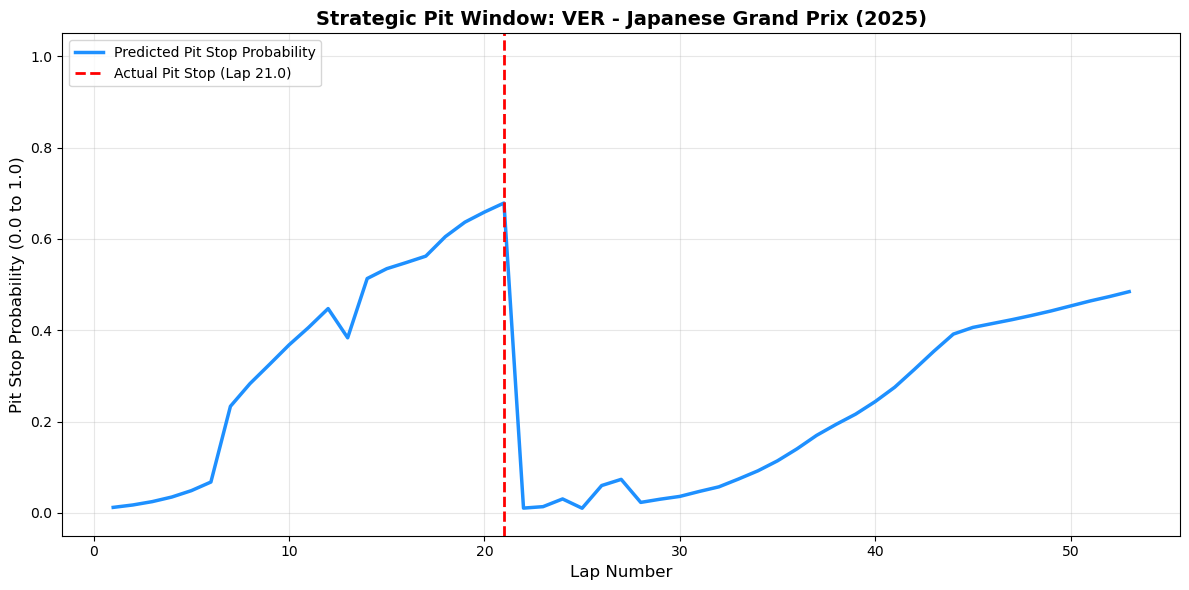

In [99]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. GENERATE PREDICTIONS (PROBABILITIES)
# ---------------------------------------------------------
print("Calculating pit stop probabilities for the Test Set...")
# .predict() returns an array of probabilities between 0.0 and 1.0
predicted_probs = model.predict(X_test, verbose=0)

# Attach the probabilities back to the original test dataframe
# We use df_test because it still contains the 'Driver', 'GP', and 'LapNumber' columns
df_test['Predicted_Pit_Prob'] = predicted_probs

# ---------------------------------------------------------
# 2. SELECT A SPECIFIC RACE AND DRIVER TO VISUALIZE
# ---------------------------------------------------------
# Automatically pick the first Grand Prix and Driver in the test set
# You can manually change these to specific strings, e.g., sample_gp = 'Italian Grand Prix'
sample_gp = df_test['GP'].iloc[0]
sample_driver = df_test[df_test['GP'] == sample_gp]['Driver'].iloc[0]

# Filter the dataframe for this specific combination
df_plot = df_test[(df_test['GP'] == sample_gp) & (df_test['Driver'] == sample_driver)]

# ---------------------------------------------------------
# 3. PLOT THE PIT WINDOW
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot the predicted probability curve
plt.plot(
    df_plot['LapNumber'], 
    df_plot['Predicted_Pit_Prob'], 
    label='Predicted Pit Stop Probability', 
    color='dodgerblue', 
    linewidth=2.5
)

# Find the exact laps where the driver ACTUALLY pitted
actual_pits = df_plot[df_plot['InPits'] == 1]['LapNumber']

# Draw a red vertical line for each actual pit stop
for pit_lap in actual_pits:
    plt.axvline(
        x=pit_lap, 
        color='red', 
        linestyle='--', 
        linewidth=2,
        label=f'Actual Pit Stop (Lap {pit_lap})'
    )

# Formatting the chart
plt.title(f"Strategic Pit Window: {sample_driver} - {sample_gp} ({test_year})", fontsize=14, fontweight='bold')
plt.xlabel("Lap Number", fontsize=12)
plt.ylabel("Pit Stop Probability (0.0 to 1.0)", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)

# Fix duplicate labels in the legend (if there are multiple pit stops)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.tight_layout()
plt.show()

Calculating pit stop probabilities for the Test Set...
Generating plots for VER across 16 races...



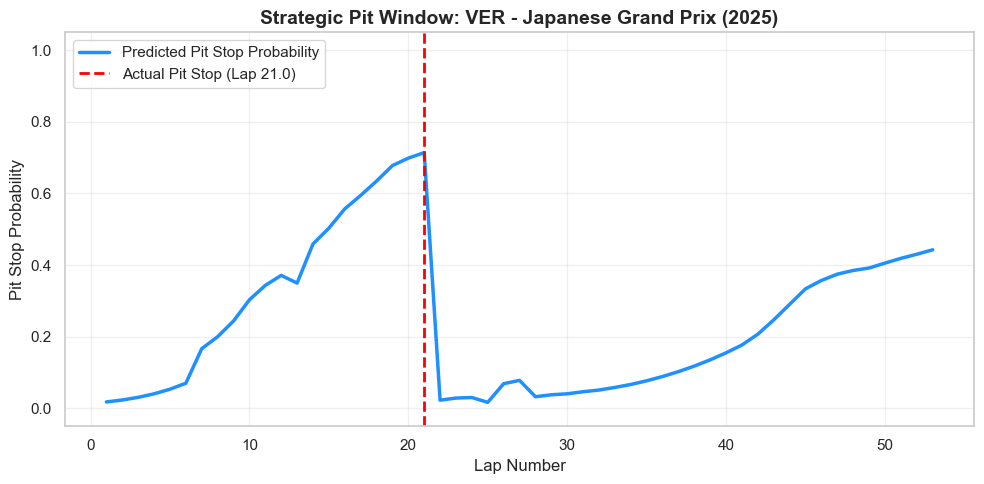

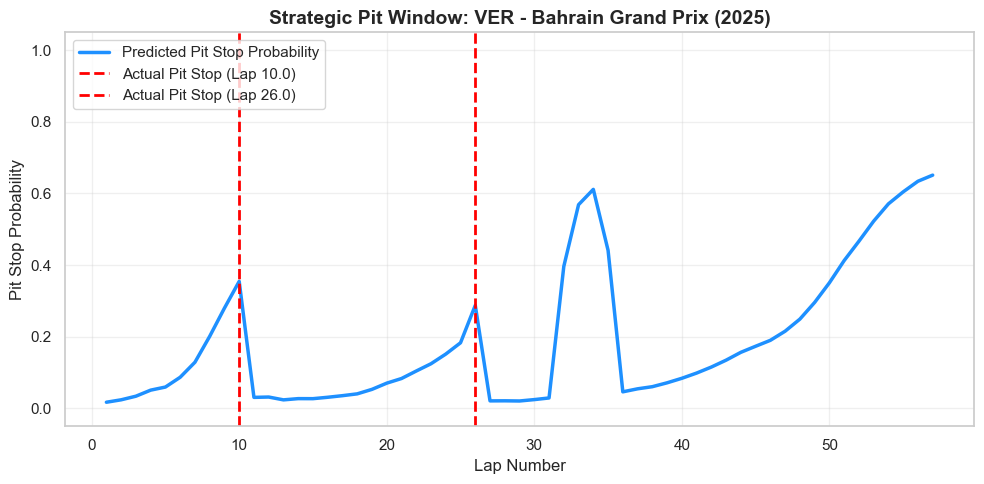

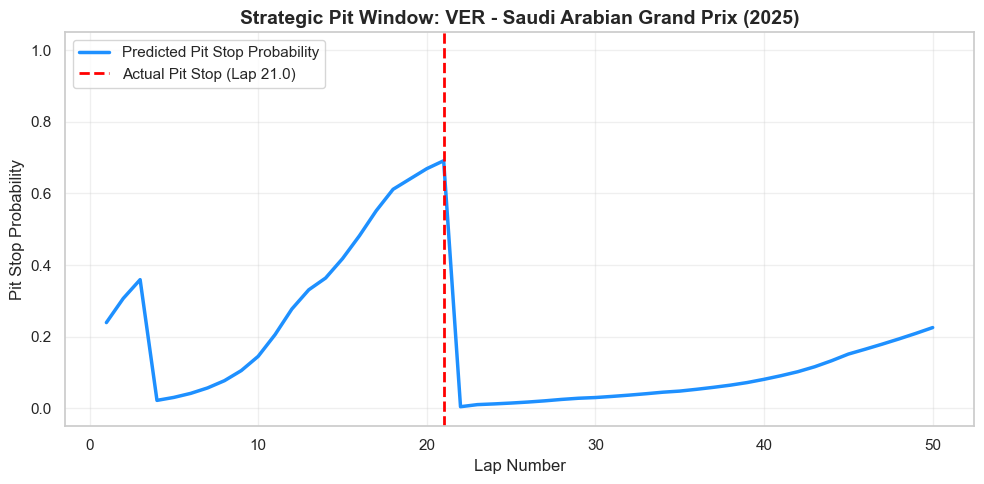

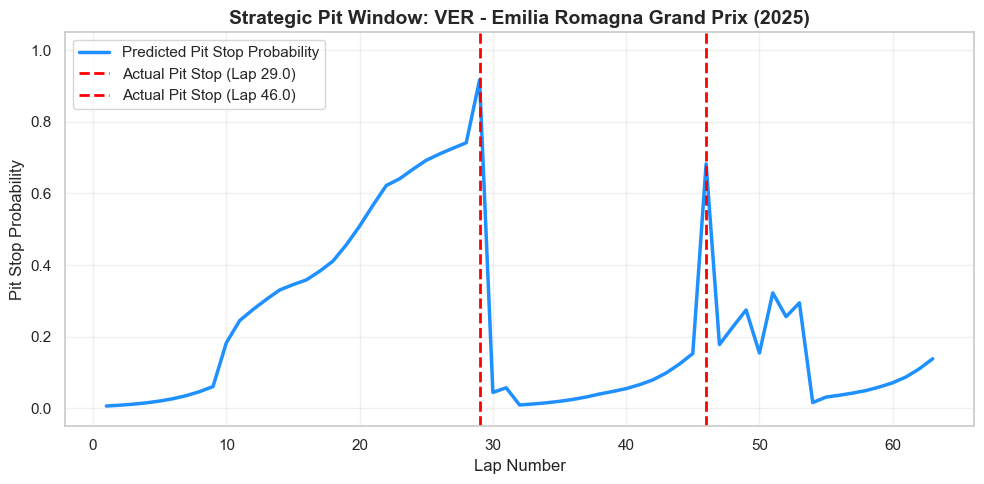

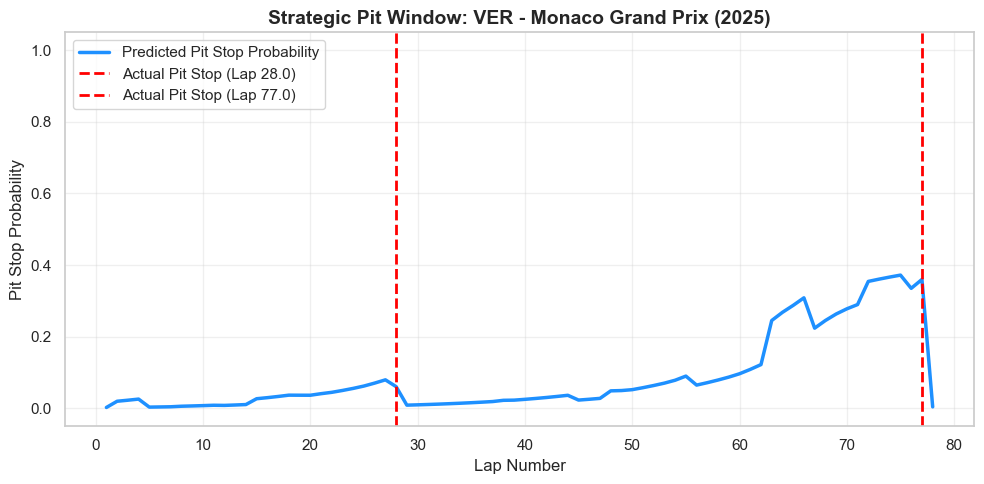

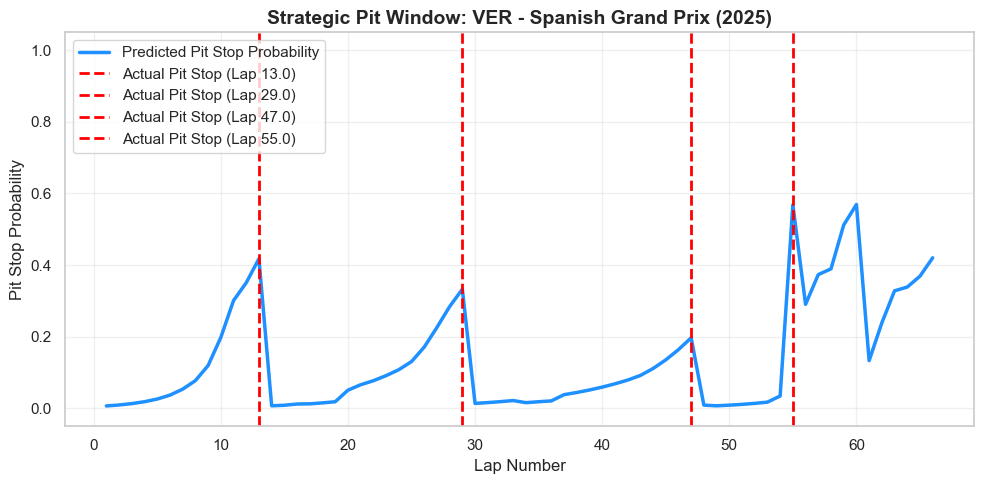

Skipping Canadian Grand Prix - No data for VER.
Skipping Austrian Grand Prix - No data for VER.


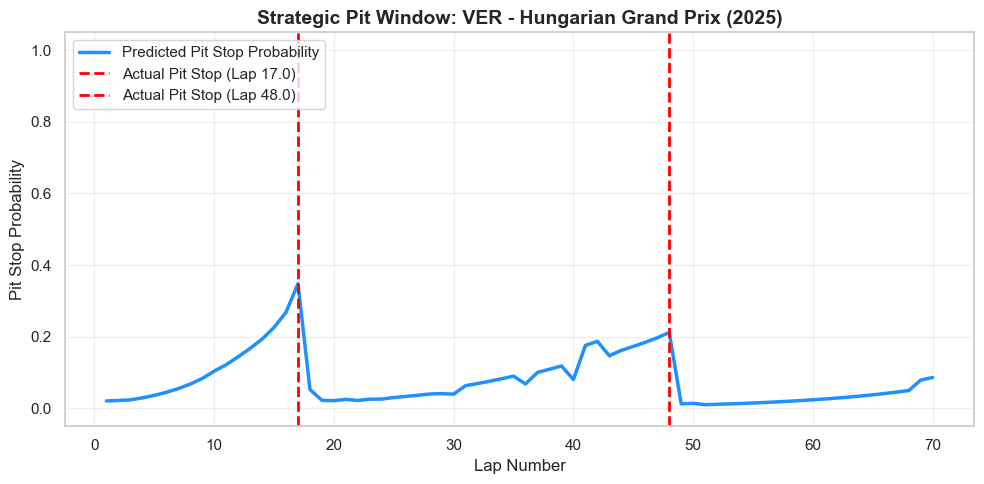

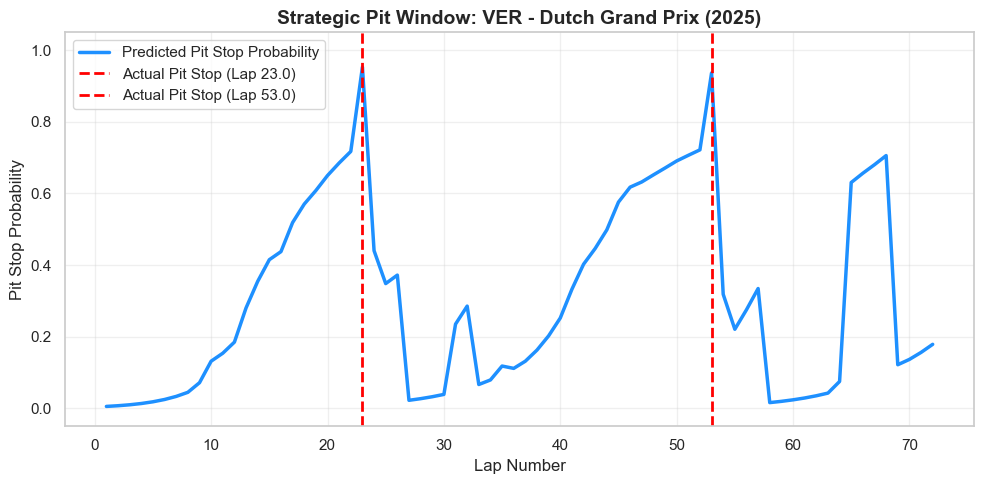

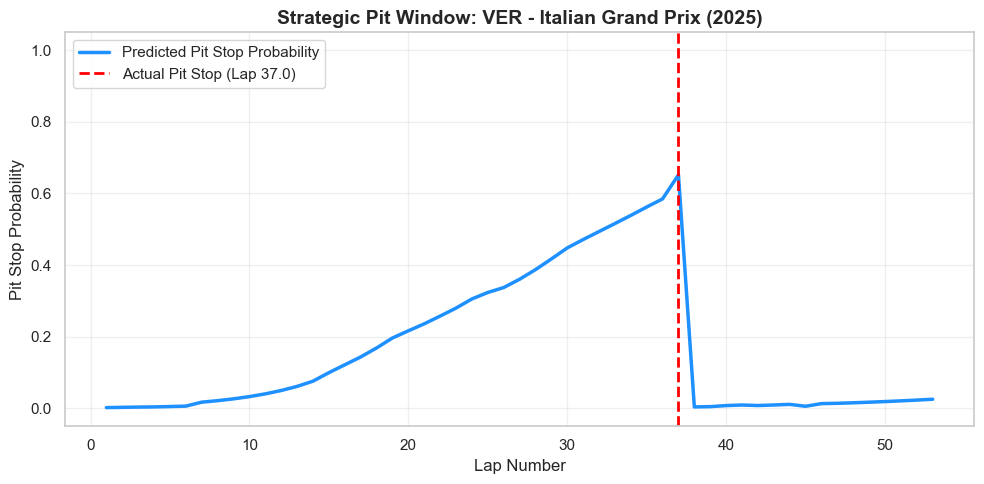

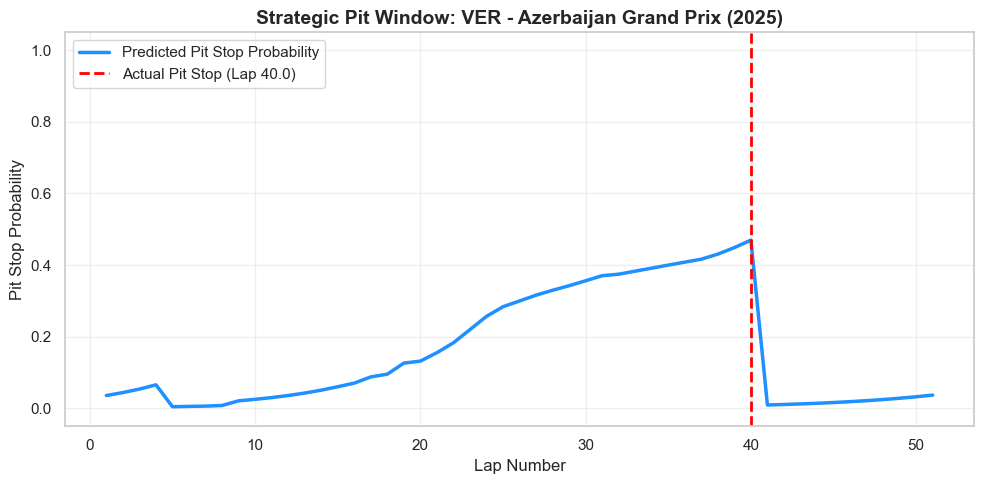

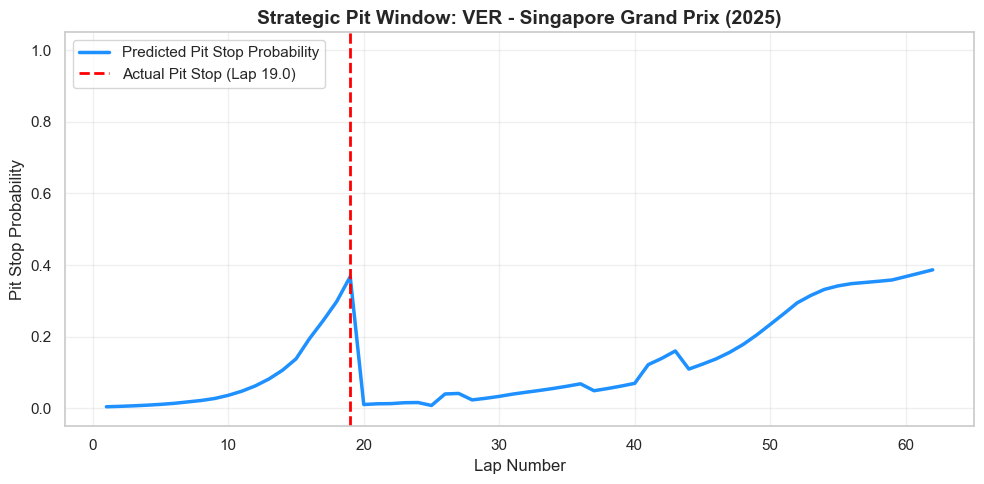

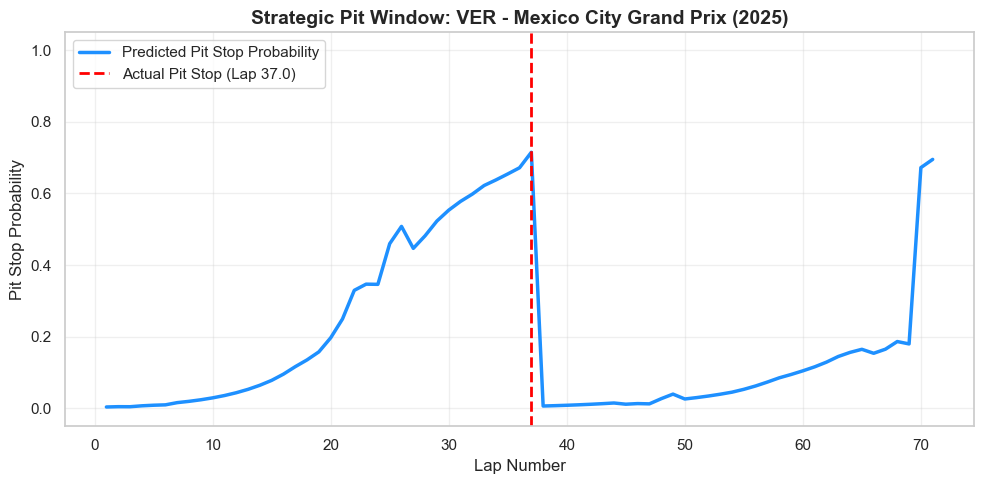

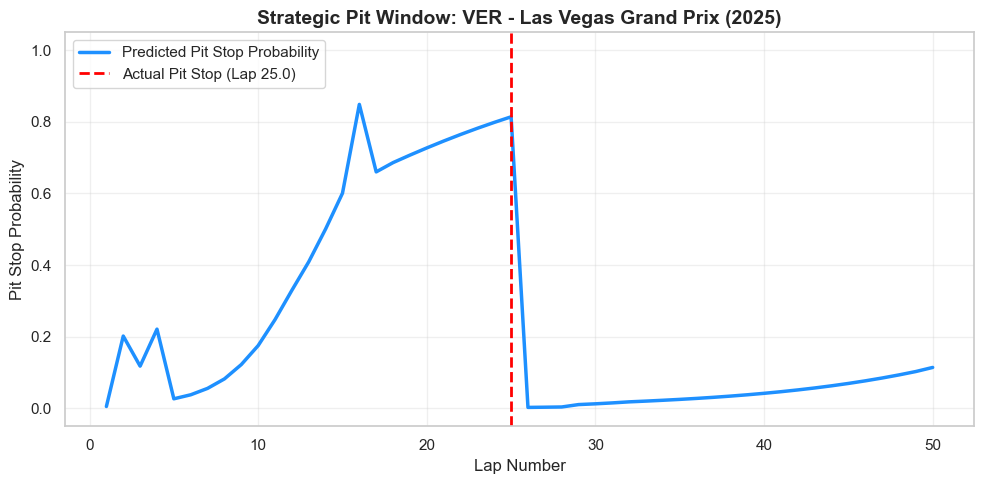

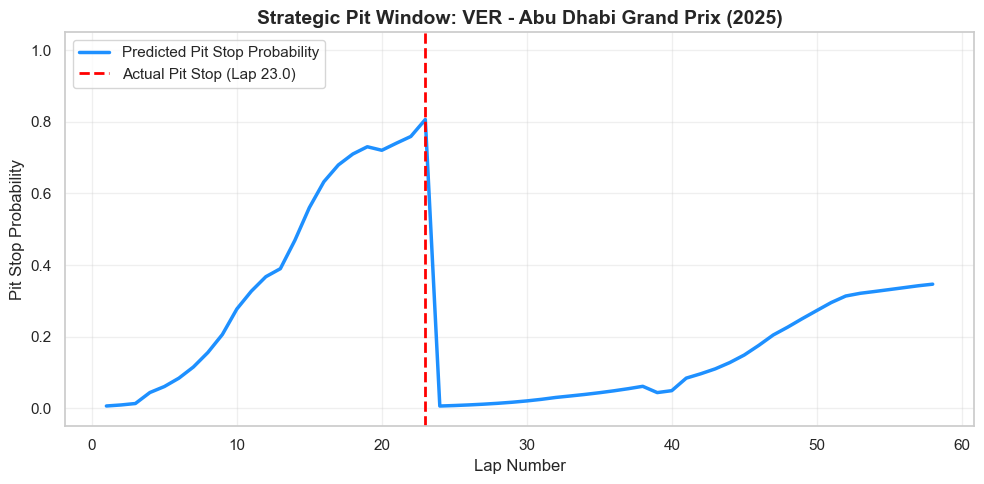

In [151]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. GENERATE PREDICTIONS (PROBABILITIES)
# ---------------------------------------------------------
print("Calculating pit stop probabilities for the Test Set...")
# We generate predictions for the whole test set at once
predicted_probs = model.predict(X_test_nn, verbose=0)
df_test_nn['Predicted_Pit_Prob'] = predicted_probs

# ---------------------------------------------------------
# 2. LOOP THROUGH EVERY RACE IN THE TEST SET
# ---------------------------------------------------------
# Get a list of all unique Grand Prix events in the test data
unique_gps = df_test_nn['GP'].unique()

# Define the driver you want to track across the season
target_driver = 'VER' # Change this to 'LEC', 'NOR', 'HAM', etc.

print(f"Generating plots for {target_driver} across {len(unique_gps)} races...\n")

for gp in unique_gps:
    # Filter the dataframe for the current loop's race and the target driver
    df_plot = df_test_nn[(df_test_nn['GP'] == gp) & (df_test_nn['Driver'] == target_driver)]
    
    # Safety check: if the driver didn't race (e.g., DNS or different team), skip to the next GP
    if df_plot.empty:
        print(f"Skipping {gp} - No data for {target_driver}.")
        continue

    # ---------------------------------------------------------
    # 3. PLOT THE PIT WINDOW
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 5)) # Slightly smaller height for easier scrolling
    
    # Plot the predicted probability curve
    plt.plot(
        df_plot['LapNumber'], 
        df_plot['Predicted_Pit_Prob'], 
        label='Predicted Pit Stop Probability', 
        color='dodgerblue', 
        linewidth=2.5
    )
    
    # Find the exact laps where the driver ACTUALLY pitted
    actual_pits = df_plot[df_plot['InPits'] == 1]['LapNumber']
    
    # Draw a red vertical line for each actual pit stop
    for pit_lap in actual_pits:
        plt.axvline(
            x=pit_lap, 
            color='red', 
            linestyle='--', 
            linewidth=2,
            label=f'Actual Pit Stop (Lap {pit_lap})'
        )
    
    # Formatting the chart
    current_year = df_plot['Year'].iloc[0]
    plt.title(f"Strategic Pit Window: {target_driver} - {gp} ({current_year})", fontsize=14, fontweight='bold')
    plt.xlabel("Lap Number", fontsize=12)
    plt.ylabel("Pit Stop Probability", fontsize=12)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, alpha=0.3)
    
    # Fix duplicate labels in the legend (crucial for multi-stop races)
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper left')
    
    plt.tight_layout()
    plt.show() # Renders the plot and then loops to the next Grand Prix

Generating advanced Seaborn plots for VER across 16 races...



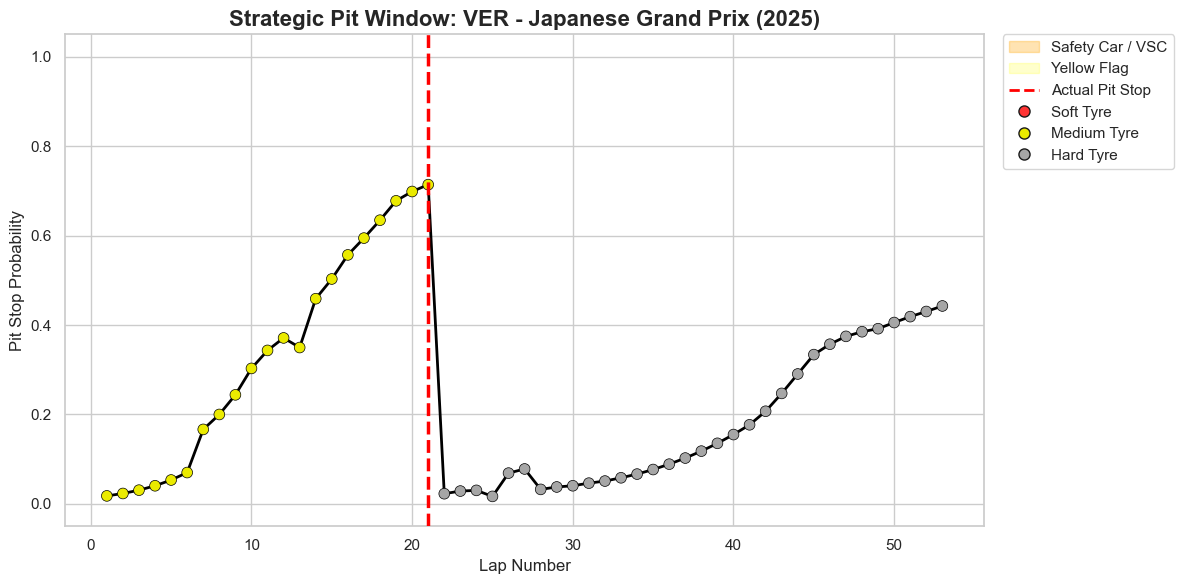

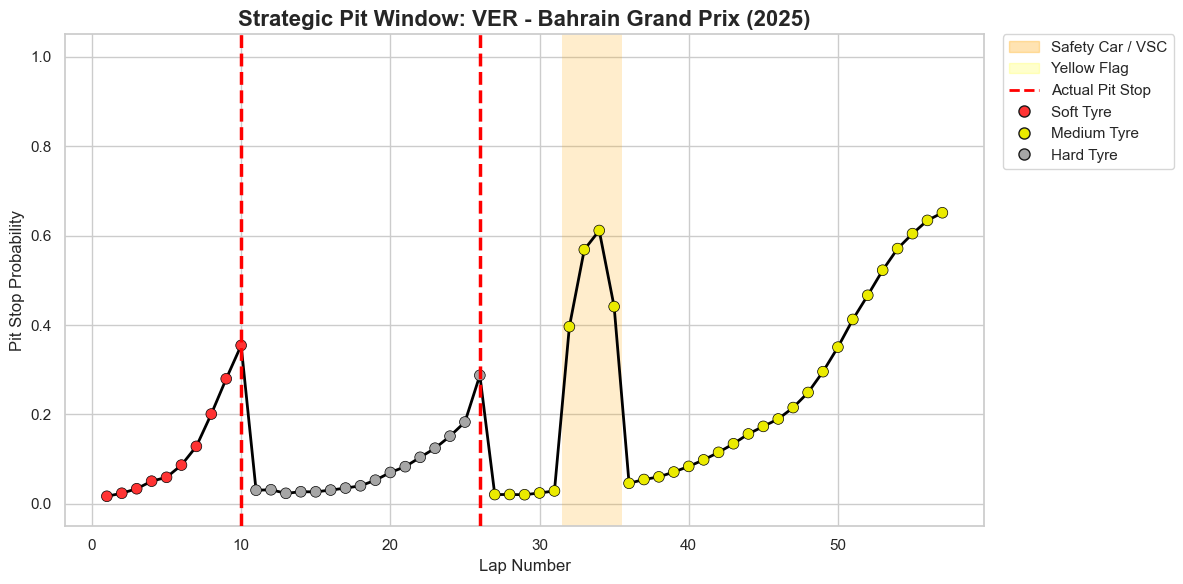

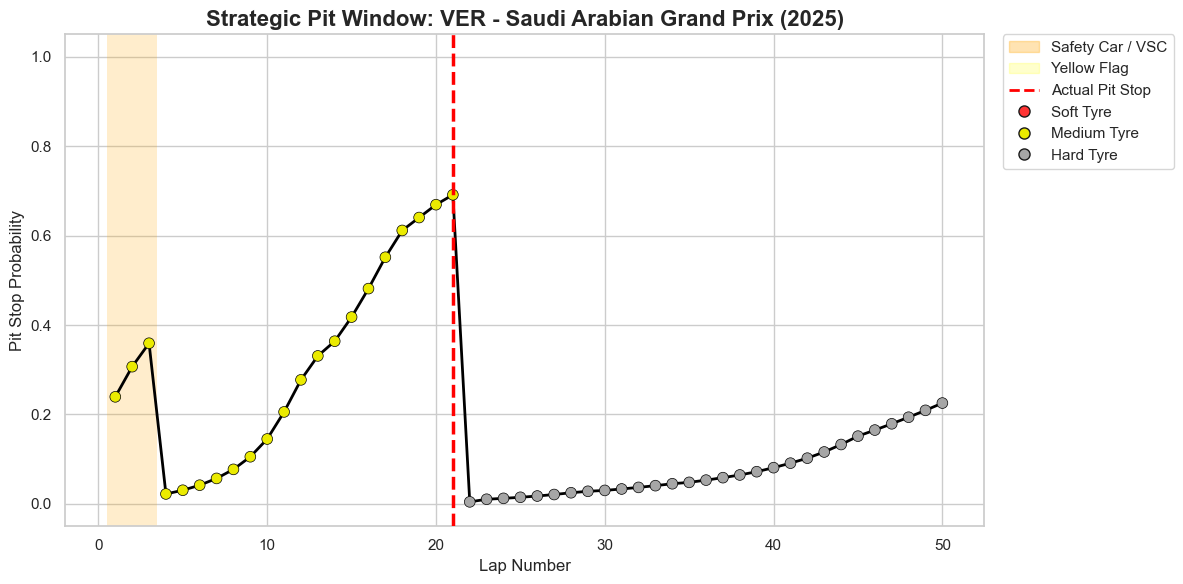

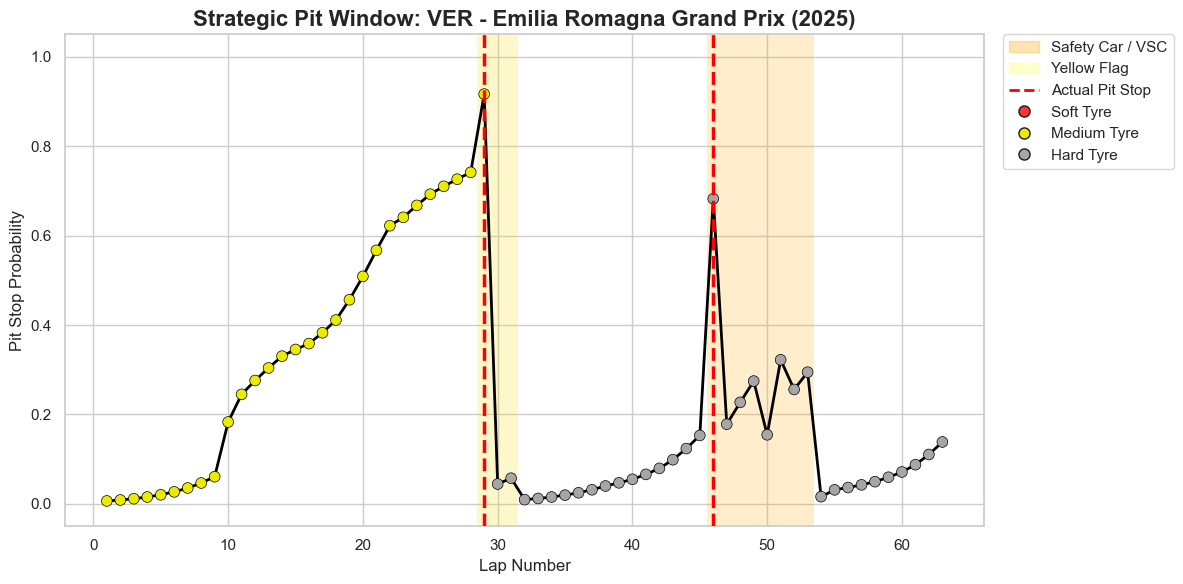

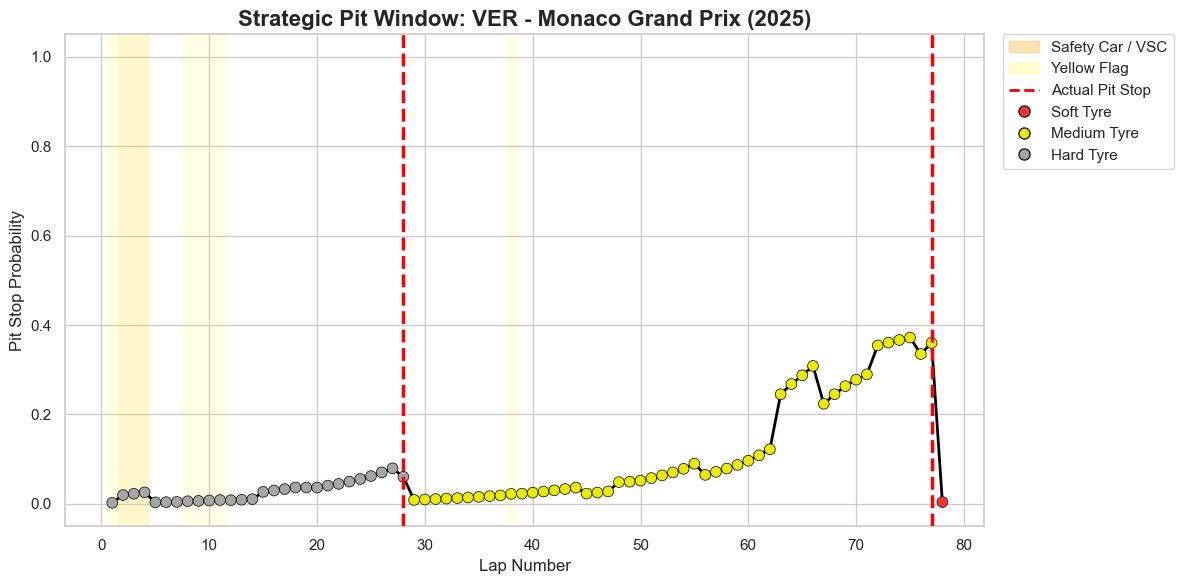

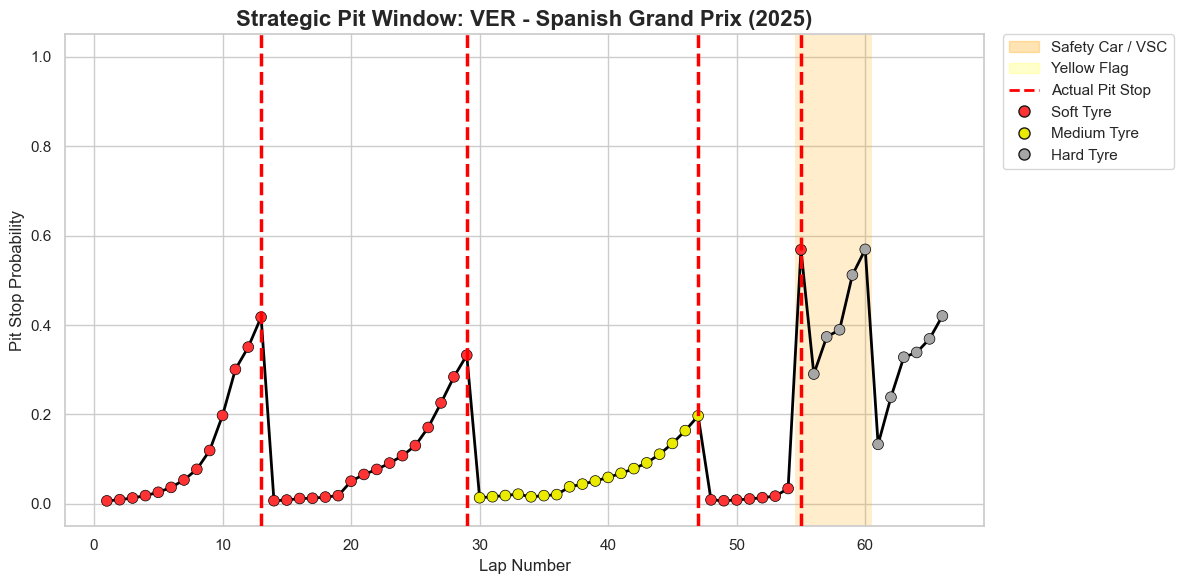

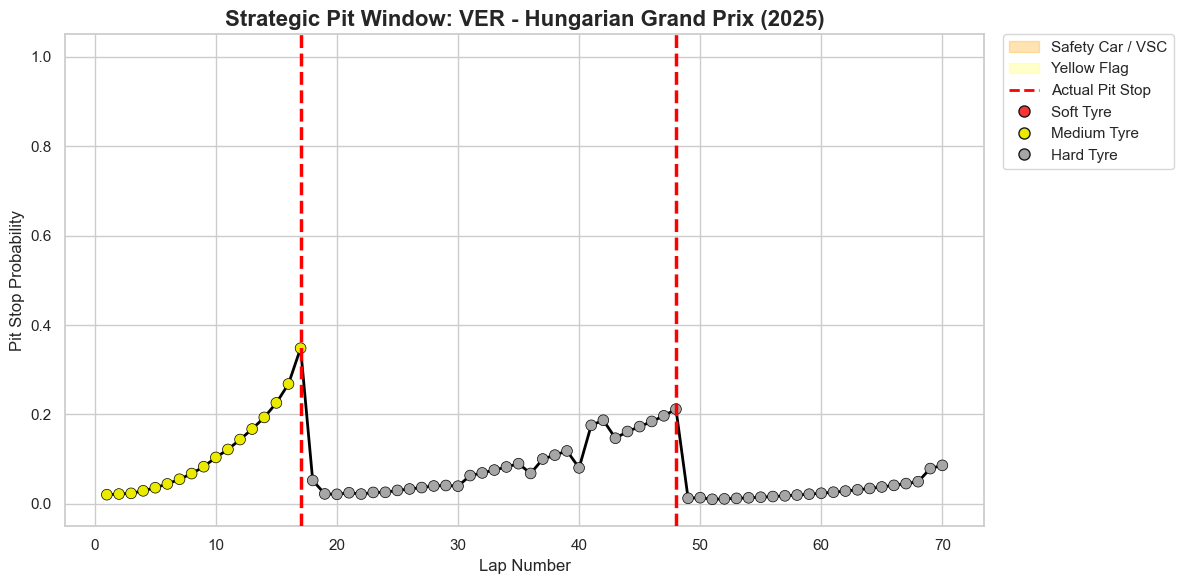

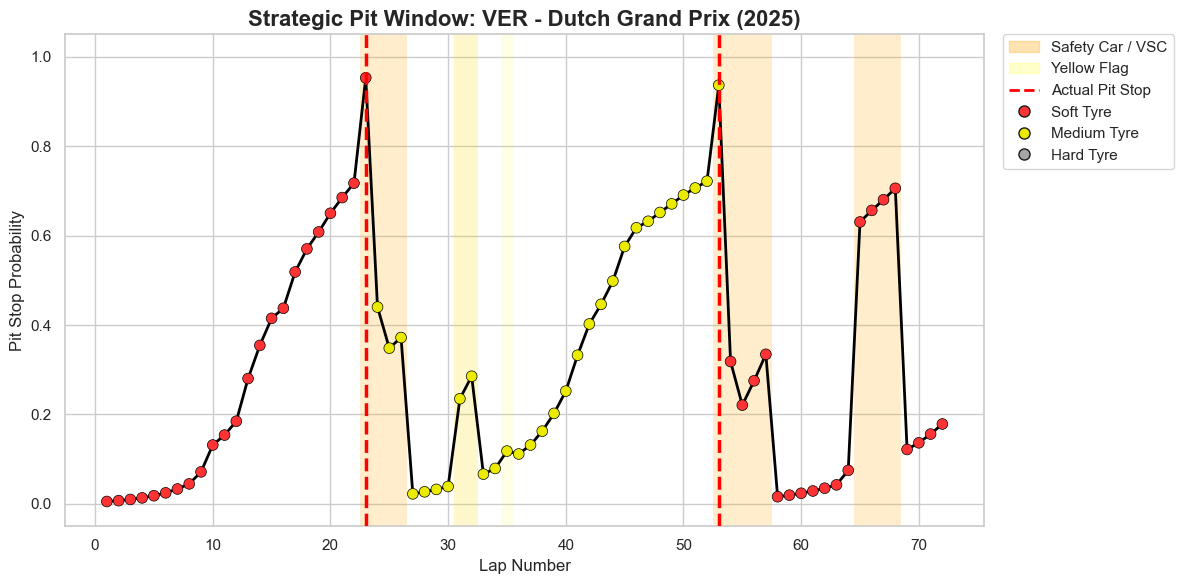

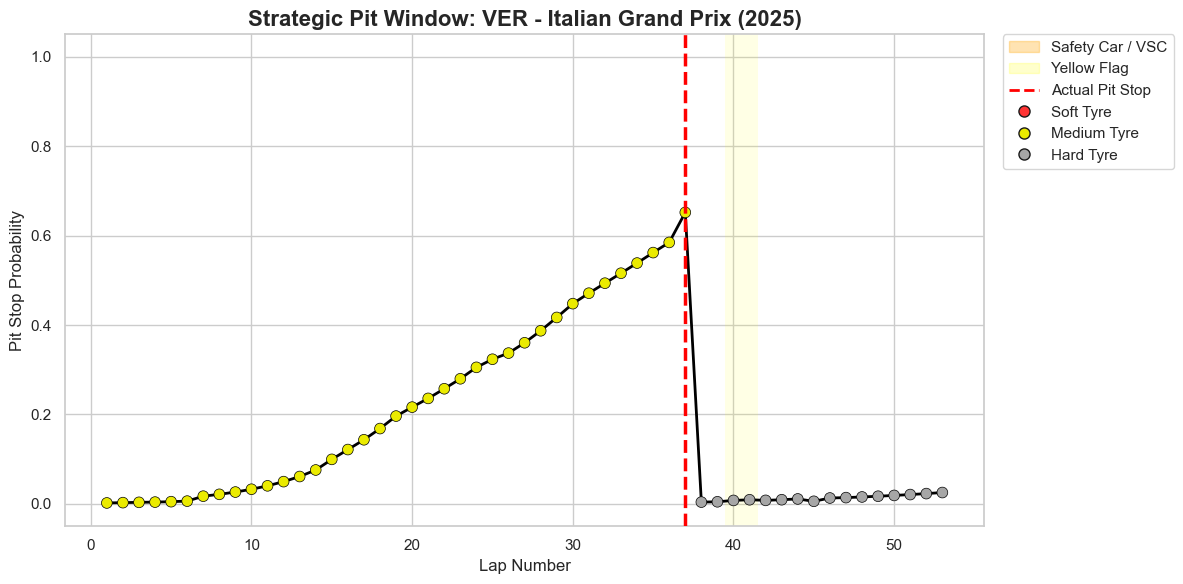

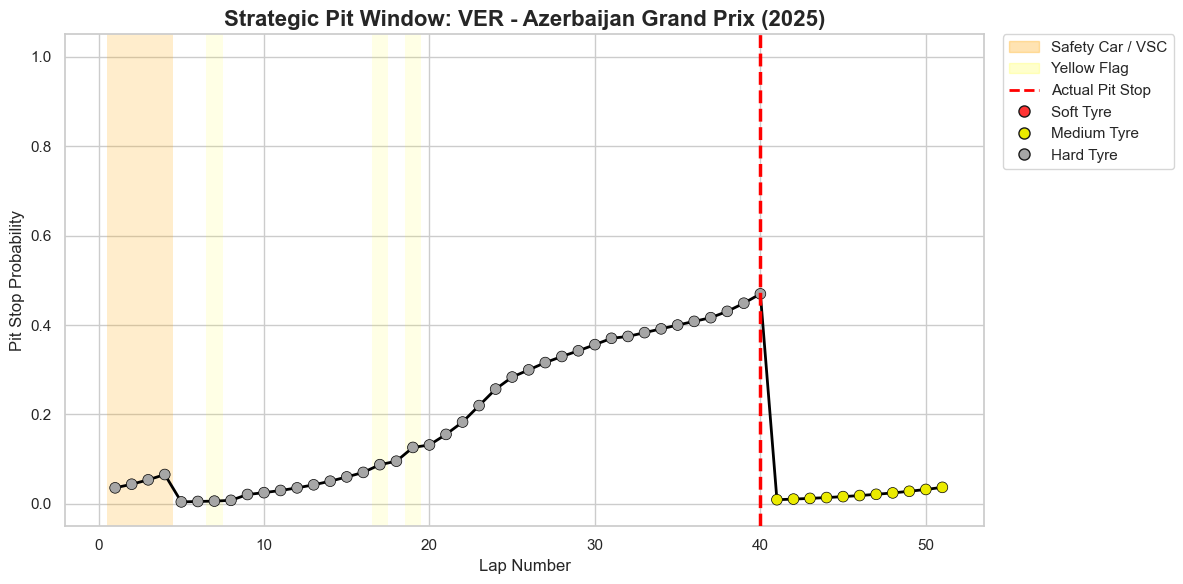

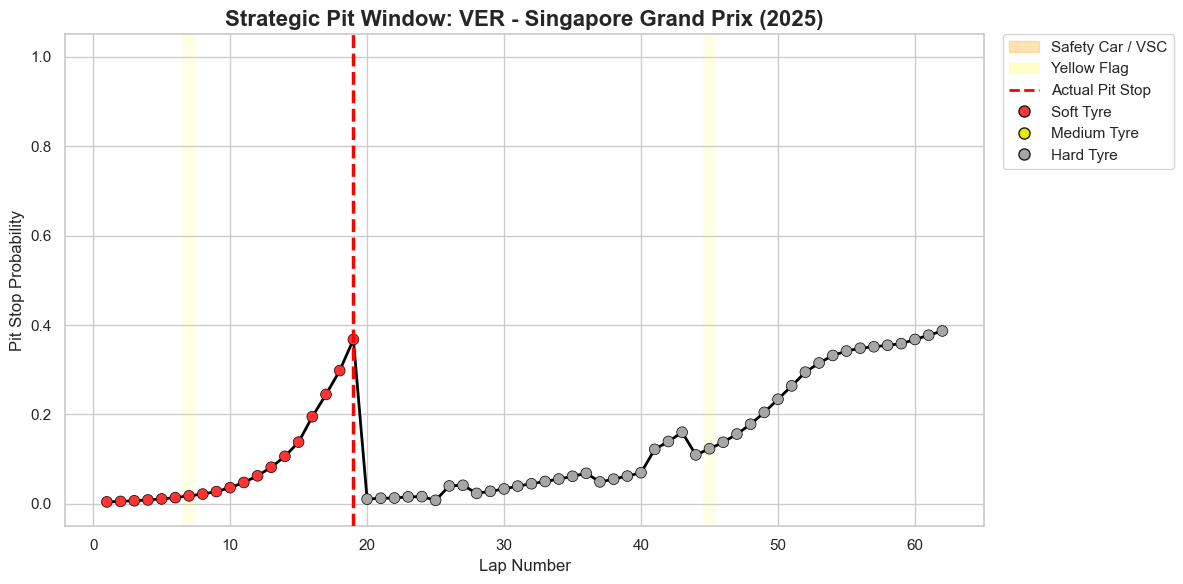

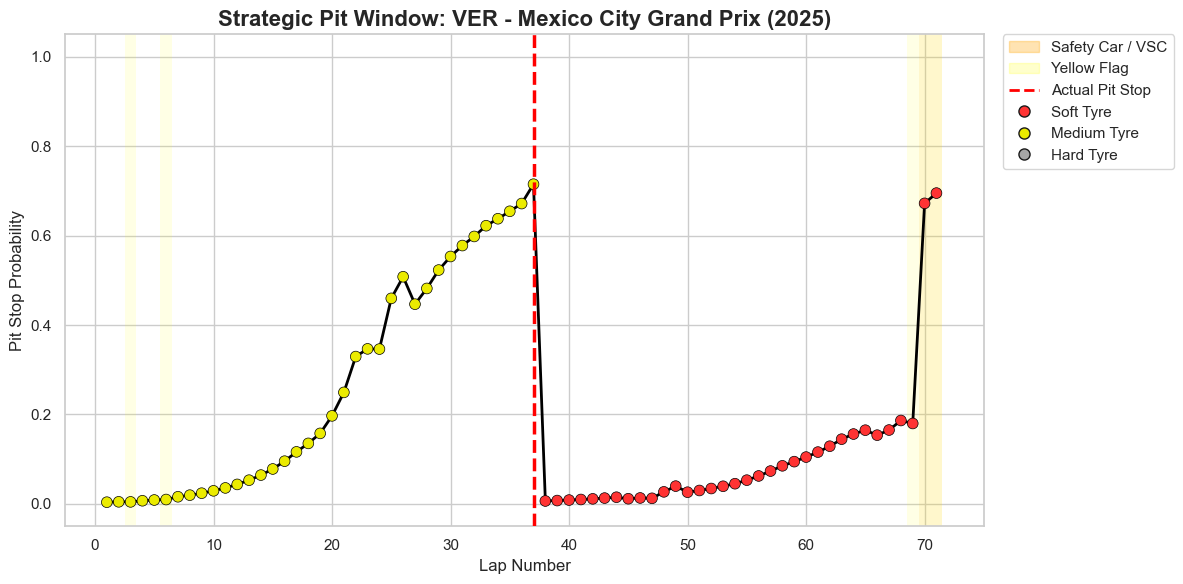

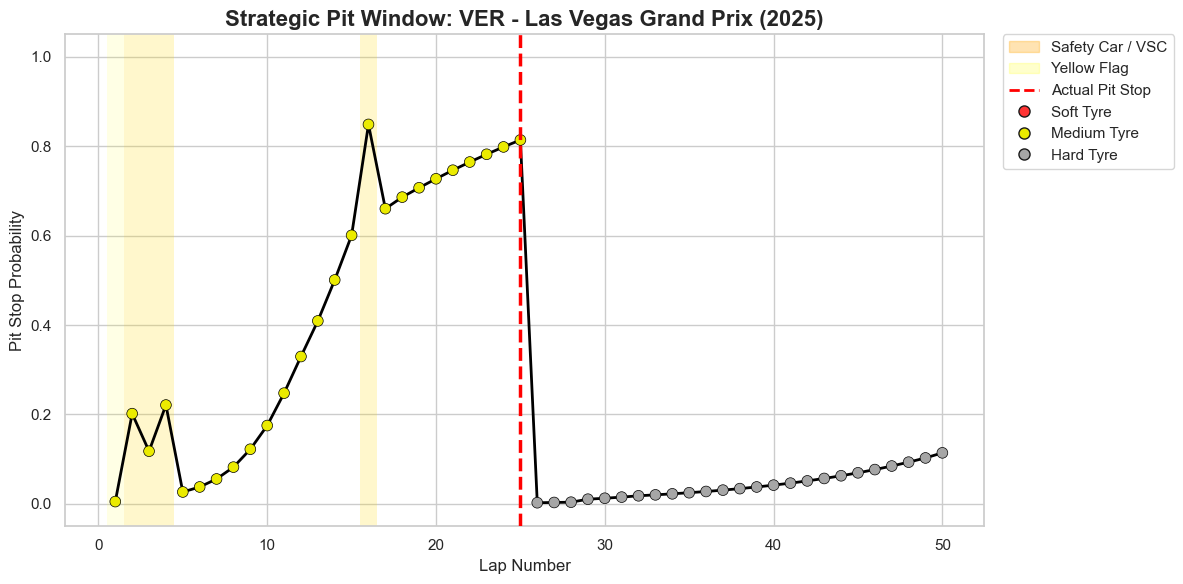

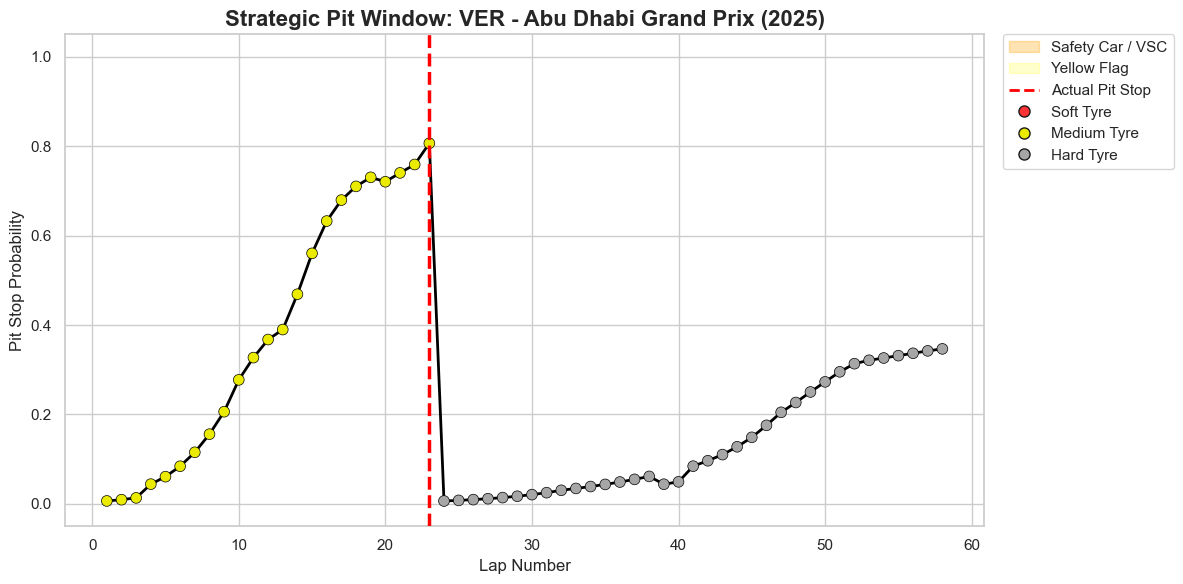

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Set Seaborn theme for a clean, professional look
sns.set_theme(style="whitegrid", palette="muted")

# ---------------------------------------------------------
# 1. HELPER FUNCTIONS FOR COLORS
# ---------------------------------------------------------
def get_status_color(row):
    """Maps the dummy TrackStatus columns to a background color."""
    if row.get('CleanTrackStatus_RedFlag', 0) == 1: return 'red', 0.2
    if row.get('CleanTrackStatus_SafetyCar', 0) == 1: return 'orange', 0.2
    if row.get('CleanTrackStatus_VSC', 0) == 1: return 'gold', 0.2
    if row.get('CleanTrackStatus_YellowFlag', 0) == 1: return 'yellow', 0.1
    return None, 0.0 # Green flag (no background)

def get_compound_color(row):
    """Maps the dummy Compound columns to the official Pirelli colors."""
    if row.get('Compound_SOFT', 0) == 1: return '#FF3333'   # Pirelli Red
    if row.get('Compound_MEDIUM', 0) == 1: return '#EBEB00' # Pirelli Yellow
    if row.get('Compound_HARD', 0) == 1: return '#A6A6A6'   # Pirelli White/Grey
    return 'black'

# ---------------------------------------------------------
# 2. LOOP THROUGH EVERY RACE IN THE TEST SET
# ---------------------------------------------------------
unique_gps = df_test_nn['GP'].unique()
target_driver = 'VER' # Change this to your preferred driver

print(f"Generating advanced Seaborn plots for {target_driver} across {len(unique_gps)} races...\n")

for gp in unique_gps:
    df_plot = df_test_nn[(df_test_nn['GP'] == gp) & (df_test_nn['Driver'] == target_driver)].copy()
    
    if df_plot.empty:
        continue

    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # ---------------------------------------------------------
    # 3. BACKGROUND: TRACK STATUS
    # ---------------------------------------------------------
    # Shade the background based on track conditions lap by lap
    for _, row in df_plot.iterrows():
        lap = row['LapNumber']
        bg_color, bg_alpha = get_status_color(row)
        if bg_color:
            # Draw a shaded rectangle for that specific lap
            ax.axvspan(lap - 0.5, lap + 0.5, color=bg_color, alpha=bg_alpha, lw=0)

    # ---------------------------------------------------------
    # 4. MAIN LINE: PROBABILITY
    # ---------------------------------------------------------
    sns.lineplot(
        data=df_plot, 
        x='LapNumber', 
        y='Predicted_Pit_Prob', 
        color='black', 
        linewidth=2,
        ax=ax,
        zorder=3 # Ensures the line is drawn on top of the background
    )
    
    # ---------------------------------------------------------
    # 5. SCATTER POINTS: TYRE COMPOUND
    # ---------------------------------------------------------
    # Plot dots on the line to show which tyre compound was equipped
    compound_colors = [get_compound_color(row) for _, row in df_plot.iterrows()]
    ax.scatter(
        df_plot['LapNumber'], 
        df_plot['Predicted_Pit_Prob'], 
        color=compound_colors, 
        s=60, # Size of the dots
        zorder=4,
        edgecolor='black',
        linewidth=0.5
    )

    # ---------------------------------------------------------
    # 6. VERTICAL LINES: ACTUAL PIT STOPS
    # ---------------------------------------------------------
    actual_pits = df_plot[df_plot['InPits'] == 1]['LapNumber']
    for pit_lap in actual_pits:
        ax.axvline(x=pit_lap, color='red', linestyle='--', linewidth=2.5, zorder=5)

    # ---------------------------------------------------------
    # 7. CUSTOM LEGEND & FORMATTING
    # ---------------------------------------------------------
    current_year = df_plot['Year'].iloc[0]
    ax.set_title(f"Strategic Pit Window: {target_driver} - {gp} ({current_year})", fontsize=16, fontweight='bold')
    ax.set_xlabel("Lap Number", fontsize=12)
    ax.set_ylabel("Pit Stop Probability", fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    
    # Create custom legend elements
    legend_elements = [
        mpatches.Patch(color='orange', alpha=0.3, label='Safety Car / VSC'),
        mpatches.Patch(color='yellow', alpha=0.2, label='Yellow Flag'),
        plt.Line2D([0], [0], color='red', linestyle='--', lw=2, label='Actual Pit Stop'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF3333', markersize=8, markeredgecolor='k', label='Soft Tyre'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#EBEB00', markersize=8, markeredgecolor='k', label='Medium Tyre'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#A6A6A6', markersize=8, markeredgecolor='k', label='Hard Tyre')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

    plt.tight_layout()
    plt.show()

Calculating Feature Importance via Permutation (this might take a minute)...
Baseline Test AUC: 0.8585


C:\Users\lucam\AppData\Local\Temp\ipykernel_19264\4069905630.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


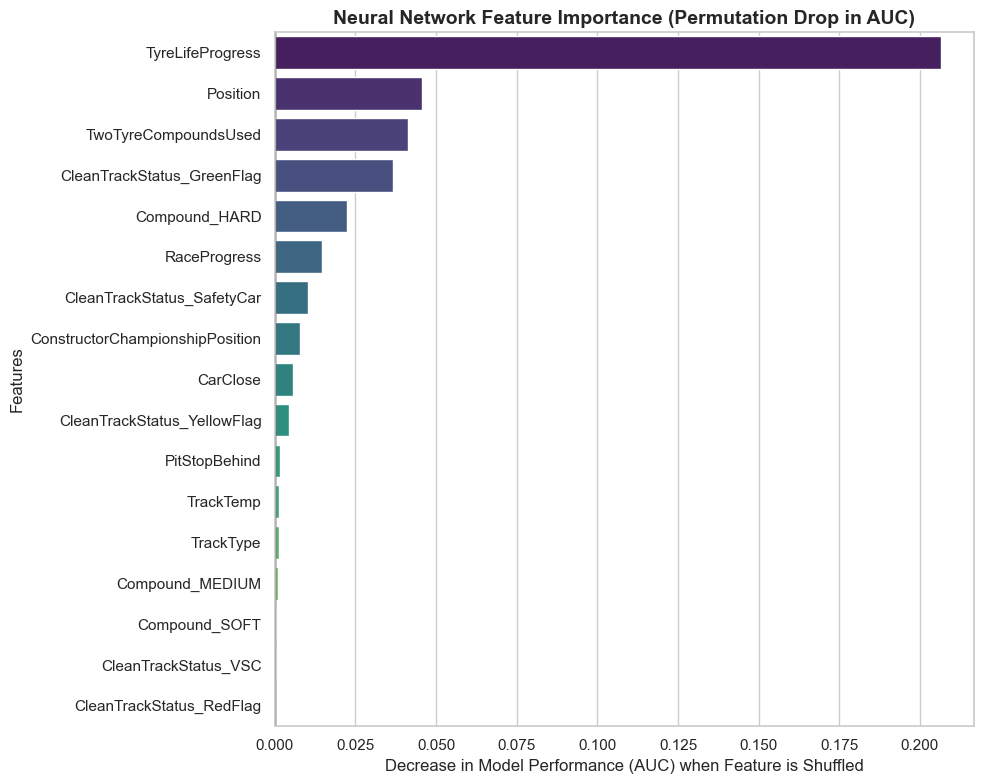


Top 5 Most Important Features:


,Feature,Importance_Score
0,TyreLifeProgress,0.206422
1,Position,0.045702
2,TwoTyreCompoundsUsed,0.041426
3,CleanTrackStatus_GreenFlag,0.036512
4,Compound_HARD,0.022333


In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

print("Calculating Feature Importance via Permutation (this might take a minute)...")

# ---------------------------------------------------------
# 1. CALCULATE BASELINE PERFORMANCE
# ---------------------------------------------------------
# We use AUC as our metric because it handles imbalanced data (97% vs 3%) very well
baseline_predictions = model.predict(X_test, verbose=0)
baseline_auc = roc_auc_score(y_test, baseline_predictions)
print(f"Baseline Test AUC: {baseline_auc:.4f}")

# ---------------------------------------------------------
# 2. CALCULATE PERMUTATION IMPORTANCE
# ---------------------------------------------------------
importances = {}

# Loop through every single feature in our test set
for column in X_test.columns:
    # Create a fresh copy of the test set
    X_test_shuffled = X_test.copy()
    
    # Shuffle the rows of THIS specific column randomly to destroy its relationship with the target
    X_test_shuffled[column] = np.random.permutation(X_test_shuffled[column].values)
    
    # Predict again with the corrupted data
    shuffled_predictions = model.predict(X_test_shuffled, verbose=0)
    shuffled_auc = roc_auc_score(y_test, shuffled_predictions)
    
    # The drop in performance is the "Importance" of the feature
    # If the drop is large, the feature was very important!
    drop_in_performance = baseline_auc - shuffled_auc
    importances[column] = drop_in_performance

# ---------------------------------------------------------
# 3. FORMAT THE RESULTS
# ---------------------------------------------------------
# Convert the dictionary into a Pandas DataFrame for easy sorting and plotting
df_importance = pd.DataFrame.from_dict(importances, orient='index', columns=['Importance_Score'])
df_importance = df_importance.sort_values(by='Importance_Score', ascending=False).reset_index()
df_importance.rename(columns={'index': 'Feature'}, inplace=True)

# ---------------------------------------------------------
# 4. VISUALIZE THE FEATURE IMPORTANCE
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Create a horizontal barplot
sns.barplot(
    data=df_importance, 
    x='Importance_Score', 
    y='Feature', 
    palette='viridis'
)

plt.title("Neural Network Feature Importance (Permutation Drop in AUC)", fontsize=14, fontweight='bold')
plt.xlabel("Decrease in Model Performance (AUC) when Feature is Shuffled", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.axvline(x=0, color='black', linewidth=1) # Baseline zero

plt.tight_layout()
plt.show()

# Display the top 5 most important features as text
print("\nTop 5 Most Important Features:")
display(df_importance.head(5))

In [103]:
# ---------------------------------------------------------
# 1. SAVE THE TRAINED MODEL
# ---------------------------------------------------------
# Save the entire model to a single file. 
# The '.keras' extension is the modern standard for TensorFlow 2.x
model_filename = 'f1_strategic_model_m10.keras'
model.save(model_filename)
print(f"✅ Model successfully saved as '{model_filename}'!")
print("Next time, you can just use: model = tf.keras.models.load_model('f1_strategic_model_m10.keras')\n")

✅ Model successfully saved as 'f1_strategic_model_m10.keras'!
Next time, you can just use: model = tf.keras.models.load_model('f1_strategic_model_m10.keras')



🎲 Extracting 3 random Driver-GP combinations to test the model's adaptability...



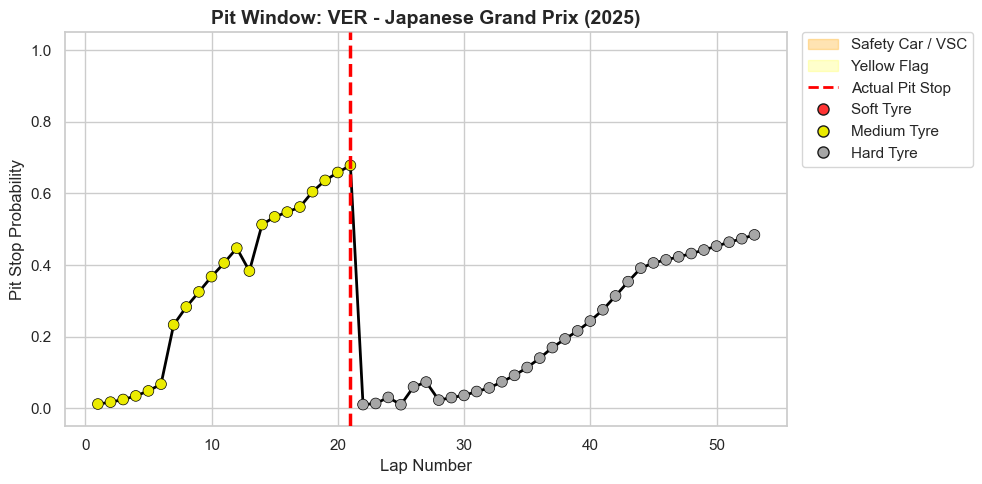

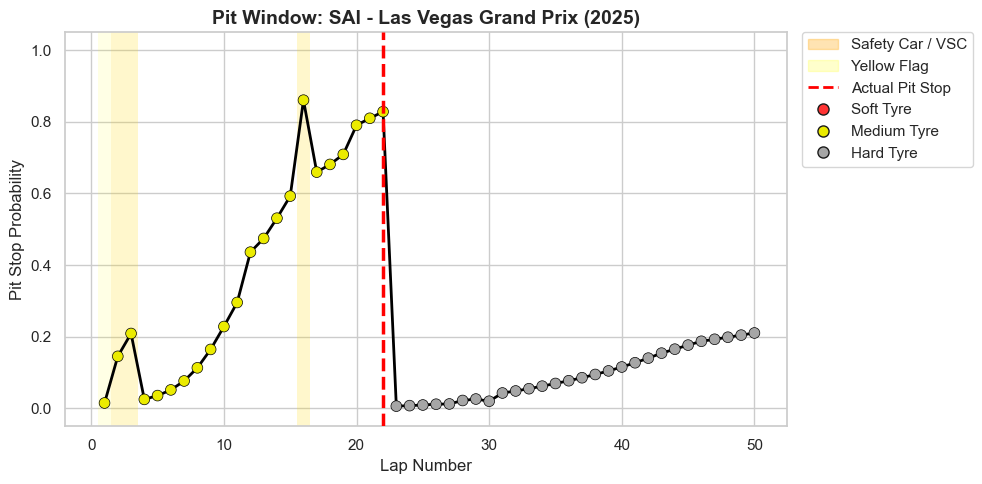

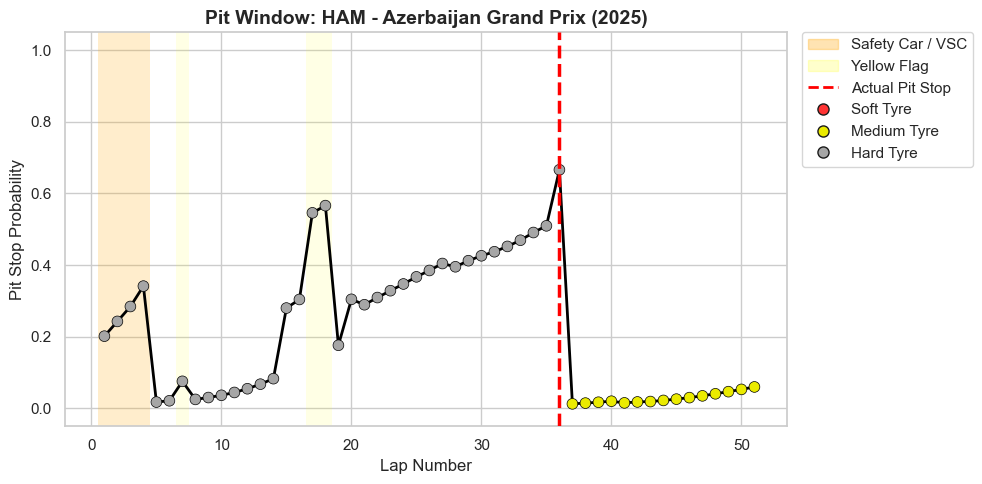

In [108]:
import random
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# ---------------------------------------------------------
# 2. EXPLORE RANDOM RACES FROM THE TEST SET
# ---------------------------------------------------------
print("🎲 Extracting 3 random Driver-GP combinations to test the model's adaptability...\n")

# Get all unique combinations of GP and Driver in the test set
unique_combos = df_test[['GP', 'Driver']].drop_duplicates().values.tolist()

# Pick 3 random combinations
random_samples = random.sample(unique_combos, 3)

# Function to plot (using our awesome seaborn setup)
def plot_random_race(gp, driver):
    df_plot = df_test[(df_test['GP'] == gp) & (df_test['Driver'] == driver)].copy()
    if df_plot.empty: return

    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Track Status Background
    for _, row in df_plot.iterrows():
        lap = row['LapNumber']
        bg_color, bg_alpha = get_status_color(row) # Using the function we defined earlier
        if bg_color:
            ax.axvspan(lap - 0.5, lap + 0.5, color=bg_color, alpha=bg_alpha, lw=0)

    # Probability Line
    sns.lineplot(data=df_plot, x='LapNumber', y='Predicted_Pit_Prob', color='black', linewidth=2, ax=ax, zorder=3)
    
    # Tyre Compound Dots
    compound_colors = [get_compound_color(row) for _, row in df_plot.iterrows()]
    ax.scatter(df_plot['LapNumber'], df_plot['Predicted_Pit_Prob'], color=compound_colors, s=60, zorder=4, edgecolor='black', linewidth=0.5)

    # Actual Pit Stops
    actual_pits = df_plot[df_plot['InPits'] == 1]['LapNumber']
    for pit_lap in actual_pits:
        ax.axvline(x=pit_lap, color='red', linestyle='--', linewidth=2.5, zorder=5)

    # Formatting
    current_year = df_plot['Year'].iloc[0]
    ax.set_title(f"Pit Window: {driver} - {gp} ({current_year})", fontsize=14, fontweight='bold')
    ax.set_xlabel("Lap Number")
    ax.set_ylabel("Pit Stop Probability")
    ax.set_ylim(-0.05, 1.05)
    
    # Custom Legend
    legend_elements = [
        mpatches.Patch(color='orange', alpha=0.3, label='Safety Car / VSC'),
        mpatches.Patch(color='yellow', alpha=0.2, label='Yellow Flag'),
        plt.Line2D([0], [0], color='red', linestyle='--', lw=2, label='Actual Pit Stop'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF3333', markersize=8, markeredgecolor='k', label='Soft Tyre'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#EBEB00', markersize=8, markeredgecolor='k', label='Medium Tyre'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#A6A6A6', markersize=8, markeredgecolor='k', label='Hard Tyre')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

    plt.tight_layout()
    plt.show()

# Generate the 3 plots
for gp, driver in random_samples:
    plot_random_race(gp, driver)

Il Simulatore Predittivo: Creare una funzione in cui inseriamo un giro "inventato" da noi (es. Siamo a Monza, giro 35, gomme Medie vecchie di 18 giri, c'è una Safety Car) e chiedere al modello di sputarci fuori la probabilità di sosta in tempo reale.

Dashboard Interattiva (Streamlit): Visto che i grafici Seaborn sono così belli, potremmo impacchettare il tutto in un mini-sito web locale con un menu a tendina. Scegli il Pilota e il Gran Premio, e lui ti genera il grafico istantaneamente.

# REGRESSOR

### DATA PREPARATION

In [38]:
import os

data_dir = './f1_data'
race_file = os.path.join(data_dir, 'f1_strategy_NN_19_25.csv')
constructor_file = os.path.join(data_dir, 'f1_constructor_results.csv')
circuit_file = os.path.join(data_dir, 'f1_circuits_clustered.csv')

df_race_reg = pd.read_csv(race_file)
df_constructor = pd.read_csv(constructor_file)
df_circuits = pd.read_csv(circuit_file)

# ---------------------------------------------------------
# 1. FIX GRAND PRIX NAMES (Excluding Sakhir)
# ---------------------------------------------------------
gp_mapping = {
    'Brazilian Grand Prix': 'São Paulo Grand Prix',
    'Mexican Grand Prix': 'Mexico City Grand Prix',
    '70th Anniversary Grand Prix': 'British Grand Prix',
    'Styrian Grand Prix': 'Austrian Grand Prix'
    # Sakhir is intentionally ignored; it will remain NaN and be dropped later
}

# Rename the GPs in the main dataframe
df_race_reg['GP'] = df_race_reg['GP'].replace(gp_mapping)

# Create a dictionary from df_circuits to map the correct Track_Archetype
track_dict = dict(zip(df_circuits['EventName'], df_circuits['Track_Archetype']))

# Overwrite the TrackType column using the updated GP names
df_race_reg['TrackType'] = df_race_reg['GP'].map(track_dict)

# ---------------------------------------------------------
# 2. FIX TEAMS (Using the updated df_constructor)
# ---------------------------------------------------------
# Drop the old column with null values if it exists
if 'ConstructorChampionshipPosition' in df_race_reg.columns:
    df_race_reg.drop(columns=['ConstructorChampionshipPosition'], inplace=True)

# Prepare the updated constructor data
constructor_data = df_constructor[['Year', 'Team', 'Position']].rename(
    columns={'Position': 'ConstructorChampionshipPosition'}
)

# Perform a new left merge to attach the correct championship positions
df_race_reg = pd.merge(df_race_reg, constructor_data, on=['Year', 'Team'], how='left')

# Normalize the values between 0.0 and 1.0
max_position = df_race_reg['ConstructorChampionshipPosition'].max()
if pd.notna(max_position) and max_position > 0:
    df_race_reg['ConstructorChampionshipPosition'] = df_race_reg['ConstructorChampionshipPosition'] / max_position

In [39]:
# ---------------------------------------------------------
# 3. FINAL CLEANUP (Drop remaining NaNs)
# ---------------------------------------------------------
# Drop the laps missing the Compound data
df_race_reg.dropna(subset=['Compound'], inplace=True)

# Drop the races that don't have a TrackType (Sakhir, Russia, Mugello, etc.)
df_race_reg.dropna(subset=['TrackType'], inplace=True)

# Drop any remaining rows where the constructor couldn't be mapped
df_race_reg.dropna(subset=['ConstructorChampionshipPosition'], inplace=True)

# Drop rows where 'Position' is missing (crucial feature for M10 model)
df_race_reg.dropna(subset=['Position'], inplace=True)

# Drop rows where 'LapTime' is missing
df_race_reg.dropna(subset=['LapTime'], inplace=True)

# Drop all rows where the 'Compound' is exactly 'UNKNOWN'
df_race_reg.drop(df_race_reg[df_race_reg['Compound'] == 'UNKNOWN'].index, inplace=True)


In [40]:
cols_to_drop = [
    'Sector1Time', 'Sector2Time', 'Sector3Time', 
    'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
    'Time', 'Stint', 'PitOutTime', 'PitInTime', # Massive data leaks for 'InPits'!
    'FreshTyre', 'Deleted', 'IsAccurate', 'GapToCarAhead', 'GapToCarBehind', 'RealTrackPosition',
]
df_race_reg.drop(columns=cols_to_drop, errors='ignore', inplace=True)


In [41]:
df_race_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111815 entries, 0 to 120434
Data columns (total 20 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Driver                           111815 non-null  object 
 1   LapTime                          111815 non-null  object 
 2   LapNumber                        111815 non-null  float64
 3   Compound                         111815 non-null  object 
 4   TyreLife                         111815 non-null  float64
 5   Team                             111815 non-null  object 
 6   TrackStatus                      111815 non-null  float64
 7   Position                         111815 non-null  float64
 8   LapTime_ms                       111815 non-null  float64
 9   InPits                           111815 non-null  bool   
 10  TrackTemp                        111815 non-null  float64
 11  Year                             111815 non-null  int64  
 12  GP     

In [42]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. IDENTIFY CLEAN LAPS TO CALCULATE THE BASELINE
# ---------------------------------------------------------
# We want to find the true pace, so we exclude Lap 1 (standing start),
# laps with pit stops, and any lap that isn't purely Green Flag (TrackStatus == 1.0).
clean_laps_mask = (
    (df_race_reg['LapNumber'] > 1) & 
    (df_race_reg['InPits'] == False) & 
    (df_race_reg['TrackStatus'] == 1.0) 
)

clean_laps = df_race_reg[clean_laps_mask]

# ---------------------------------------------------------
# 2. CALCULATE THE 5TH PERCENTILE (ROBUST FASTEST LAP)
# ---------------------------------------------------------
# Group by Year and GP to find the ideal pace for each specific race.
# Using 0.05 (5th percentile) cuts out the extreme low fuel/new tyre anomalies.
baseline_pace = clean_laps.groupby(['Year', 'GP'])['LapTime_ms'].quantile(0.05).reset_index()
baseline_pace.rename(columns={'LapTime_ms': 'Baseline_LapTime_ms'}, inplace=True)

# ---------------------------------------------------------
# 3. MERGE AND CALCULATE DELTA
# ---------------------------------------------------------
# Attach the baseline back to our main dataframe
df_race_reg = pd.merge(df_race_reg, baseline_pace, on=['Year', 'GP'], how='left')

# Calculate the Delta in seconds (LapTime - Baseline)
df_race_reg['LapDeltaSeconds'] = (df_race_reg['LapTime_ms'] - df_race_reg['Baseline_LapTime_ms']) / 1000.0

# ---------------------------------------------------------
# 4. FILTER THE DATAFRAME FOR XGBOOST TRAINING
# ---------------------------------------------------------
print(f"Original rows in df_race_reg: {len(df_race_reg)}")

# We only want XGBoost to learn tyre degradation and fuel burn.
# We shouldn't feed it Safety Car laps or laps where a driver went off track (+20s).
xgb_training_mask = (
    (df_race_reg['LapNumber'] > 1) & 
    (df_race_reg['InPits'] == False) & 
    (df_race_reg['TrackStatus'] == 1.0) &
    (df_race_reg['LapDeltaSeconds'] < 12.0) & # Ignore laps more than 12s off pace (mistakes, heavy traffic)
    (df_race_reg['LapDeltaSeconds'] > -3.0)   # Ignore negative anomalies
)

df_xgb = df_race_reg[xgb_training_mask].copy()

# Drop the temporary baseline column
df_xgb.drop(columns=['Baseline_LapTime_ms'], inplace=True)

print(f"Clean rows ready for XGBoost: {len(df_xgb)}")

# Display a quick sanity check of our new Target variable
display(df_xgb[['Driver', 'LapNumber', 'Compound', 'LapDeltaSeconds']].head(5))

Original rows in df_race_reg: 111815
Clean rows ready for XGBoost: 96719


,Driver,LapNumber,Compound,LapDeltaSeconds
19,BOT,2.0,SOFT,2.13885
20,HAM,2.0,SOFT,2.23585
21,VET,2.0,SOFT,2.57185
22,VER,2.0,SOFT,2.52985
23,LEC,2.0,SOFT,3.11285


In [43]:
df_xgb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96719 entries, 19 to 111814
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Driver                           96719 non-null  object 
 1   LapTime                          96719 non-null  object 
 2   LapNumber                        96719 non-null  float64
 3   Compound                         96719 non-null  object 
 4   TyreLife                         96719 non-null  float64
 5   Team                             96719 non-null  object 
 6   TrackStatus                      96719 non-null  float64
 7   Position                         96719 non-null  float64
 8   LapTime_ms                       96719 non-null  float64
 9   InPits                           96719 non-null  bool   
 10  TrackTemp                        96719 non-null  float64
 11  Year                             96719 non-null  int64  
 12  GP                   

In [44]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. CREATE POLYNOMIAL FEATURE (Tyre drop-off)
# ---------------------------------------------------------
# We square the tyre life progress. 
# This helps XGBoost understand that tyre degradation is not a straight line,
# but a curve that drops off sharply towards the end of the stint.
df_xgb['TyreLifeProgress_Squared'] = df_xgb['TyreLifeProgress'] ** 2

# ---------------------------------------------------------
# 2. ONE-HOT ENCODING (Drivers and Compounds)
# ---------------------------------------------------------
# Check if 'Compound' still has text values or if it's already encoded
cols_to_encode = ['Driver']
if 'Compound' in df_xgb.columns and df_xgb['Compound'].dtype == 'object':
    cols_to_encode.append('Compound')

# Create dummy columns (1 and 0)
df_xgb = pd.get_dummies(df_xgb, columns=cols_to_encode, drop_first=False)

# Convert boolean values (True/False) to integers (1/0) for XGBoost
encoded_cols = [col for col in df_xgb.columns if 'Driver_' in col or 'Compound_' in col]
for col in encoded_cols:
    df_xgb[col] = df_xgb[col].astype(int)

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. TEMPORAL SPLIT (Match Neural Network's Test Set)
# ---------------------------------------------------------
# Identify the test year (same as we did for the Neural Network)
test_year = df_xgb['Year'].max()

# Create masks to separate historical data from unseen test data
train_val_mask = df_xgb['Year'] < test_year
test_mask = df_xgb['Year'] == test_year

df_train_val_xgb = df_xgb[train_val_mask].copy()
df_test_xgb = df_xgb[test_mask].copy()

# ---------------------------------------------------------
# 2. DEFINE FEATURES (X) AND TARGET (y)
# ---------------------------------------------------------
# The target is the delta we calculated earlier
y_train_val_xgb = df_train_val_xgb['LapDeltaSeconds']
y_test_xgb = df_test_xgb['LapDeltaSeconds']

# Define metadata columns to drop from the feature sets
# We drop 'LapTime' and 'LapTime_ms' to prevent severe data leakage
cols_to_drop = [
    'LapTime', 'LapTime_ms', 'Team', 'GP', 'Year', 
    'TrackStatus', 'InPits', 'LapDeltaSeconds'
]

X_train_val_xgb = df_train_val_xgb.drop(columns=cols_to_drop, errors='ignore')
X_test_xgb = df_test_xgb.drop(columns=cols_to_drop, errors='ignore')

# ---------------------------------------------------------
# 3. SPLIT TRAIN AND VALIDATION SETS
# ---------------------------------------------------------
# We split the historical data into Train (80%) and Validation (20%)
# for XGBoost early stopping
X_train_xgb, X_valid_xgb, y_train_xgb, y_valid_xgb = train_test_split(
    X_train_val_xgb, y_train_val_xgb, 
    test_size=0.2, 
    random_state=42
)

print(f"Features ready for XGBoost: {X_train_xgb.shape[1]}")
print(f"Train samples: {X_train_xgb.shape[0]} | Validation samples: {X_valid_xgb.shape[0]} | Test samples: {X_test_xgb.shape[0]}")

Features ready for XGBoost: 53
Train samples: 64897 | Validation samples: 16225 | Test samples: 15597


### TRAINING REGRESSOR

In [50]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ---------------------------------------------------------
# 1. DEFINE HYPERPARAMETERS (Optimized for Clean Data)
# ---------------------------------------------------------
# We relax the subsampling because our data is now strictly filtered.
# Notice the addition of 'early_stopping_rounds' directly in the parameters!
xgb_params = {
    'n_estimators': 1500,        # Max number of trees (Early Stopping will halt this earlier)
    'learning_rate': 0.02,       # Slightly faster than V2, but still smooth
    'max_depth': 5,              # Shallow trees work best for tabular physics/time data
    'min_child_weight': 5,       # Lowered from 20 because our data is cleaner now
    'subsample': 0.8,            # Let the model see 80% of data per tree
    'colsample_bytree': 0.8,     # Let the model see 80% of features per tree
    'reg_lambda': 1.0,           # L2 Regularization (Ridge)
    'reg_alpha': 0.5,            # L1 Regularization (Lasso) to drop useless features
    'objective': 'reg:squarederror',
    'random_state': 42,
    'n_jobs': -1,                # Use all CPU cores
    'early_stopping_rounds': 50
}

print("Initializing XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(**xgb_params)

# ---------------------------------------------------------
# 2. TRAIN WITH EARLY STOPPING
# ---------------------------------------------------------
# We monitor the Validation set. If the error doesn't drop for 50 consecutive trees,
# training stops automatically.
print("Training the model (Watching Validation Loss)...")

# We only pass the eval_set and verbose to the fit method now.
xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_valid_xgb, y_valid_xgb)],
    verbose=100  # Print progress every 100 trees
)

# ---------------------------------------------------------
# 3. EVALUATE ON THE UNSEEN TEST SET
# ---------------------------------------------------------
print("\n🏁 Evaluating on the completely unseen Test Set...")
y_pred = xgb_model.predict(X_test_xgb)

# Calculate metrics
mae = mean_absolute_error(y_test_xgb, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_xgb, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.3f} seconds")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f} seconds")

Initializing XGBoost Regressor...
Training the model (Watching Validation Loss)...
[0]	validation_0-rmse:1.46396	validation_1-rmse:1.45787
[100]	validation_0-rmse:0.93702	validation_1-rmse:0.93617
[200]	validation_0-rmse:0.84937	validation_1-rmse:0.85133
[300]	validation_0-rmse:0.80638	validation_1-rmse:0.81015
[400]	validation_0-rmse:0.78072	validation_1-rmse:0.78676
[500]	validation_0-rmse:0.76221	validation_1-rmse:0.77115
[600]	validation_0-rmse:0.74620	validation_1-rmse:0.75812
[700]	validation_0-rmse:0.73399	validation_1-rmse:0.74875
[800]	validation_0-rmse:0.72151	validation_1-rmse:0.73927
[900]	validation_0-rmse:0.71129	validation_1-rmse:0.73190
[1000]	validation_0-rmse:0.70234	validation_1-rmse:0.72568
[1100]	validation_0-rmse:0.69375	validation_1-rmse:0.71969
[1200]	validation_0-rmse:0.68669	validation_1-rmse:0.71471
[1300]	validation_0-rmse:0.67940	validation_1-rmse:0.70981
[1400]	validation_0-rmse:0.67246	validation_1-rmse:0.70565
[1499]	validation_0-rmse:0.66509	validation_

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_xgb_feature_importance(model, feature_names, top_n=15, title="XGBoost Feature Importance"):
    """
    Plots the feature importance of an XGBoost model.
    
    Parameters:
    - model: The trained XGBoost model.
    - feature_names: List or Index of feature names (e.g., X_train.columns).
    - top_n: Number of top features to display.
    - title: Title of the chart.
    """
    # ---------------------------------------------------------
    # 1. EXTRACT AND MAPPING
    # ---------------------------------------------------------
    # Get importance scores
    importances = model.feature_importances_
    
    # Create a DataFrame for easy sorting
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Sort by importance descending
    df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    
    # ---------------------------------------------------------
    # 2. VISUALIZATION
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    # Use a color palette that highlights the most important features
    sns.barplot(
        data=df_importance.head(top_n), 
        x='Importance', 
        y='Feature', 
        palette='magma'
    )
    
    plt.title(title, fontsize=15, fontweight='bold', pad=20)
    plt.xlabel("Relative Importance Score (Gain/Weight)", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print the top 5 for a quick numerical check
    print(f"\nTop 5 Features for {title}:")
    print(df_importance.head(5).to_string(index=False))
    
    return df_importance # Returns the full dataframe if you need to perform further analysis

# ---------------------------------------------------------
# EXAMPLE USAGE:
# ---------------------------------------------------------
# importance_df = plot_xgb_feature_importance(best_xgb_model, X_train.columns)

C:\Users\lucam\AppData\Local\Temp\ipykernel_1984\3857461365.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


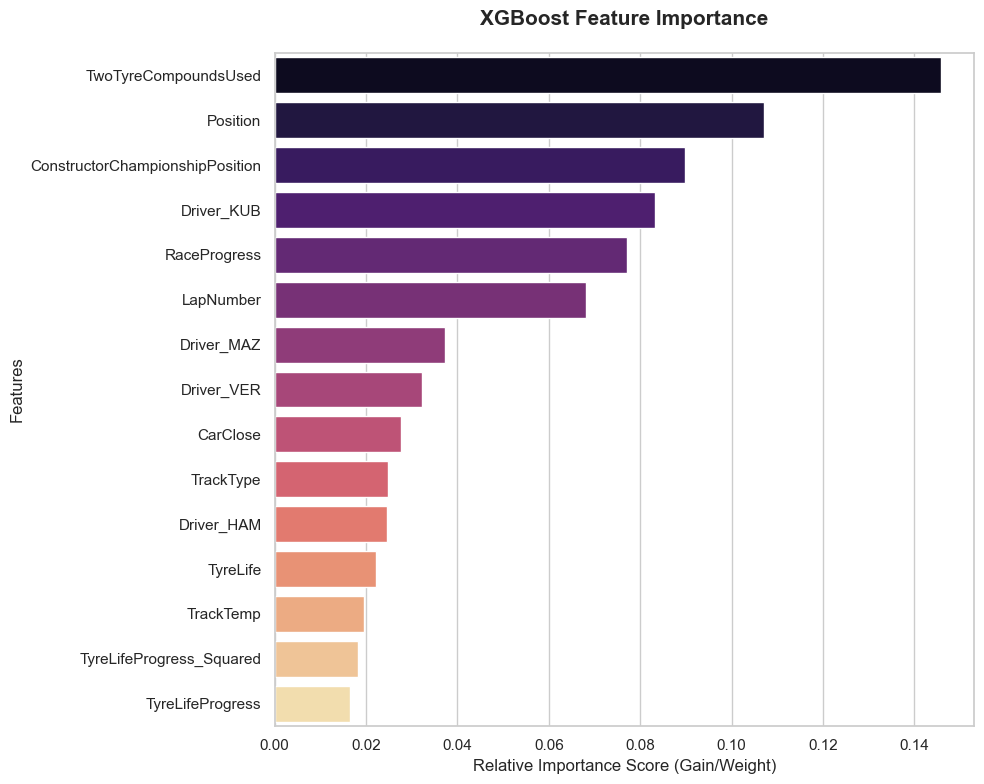


Top 5 Features for XGBoost Feature Importance:
                        Feature  Importance
           TwoTyreCompoundsUsed    0.145767
                       Position    0.107012
ConstructorChampionshipPosition    0.089758
                     Driver_KUB    0.083315
                   RaceProgress    0.077106


In [53]:
importance_df = plot_xgb_feature_importance(xgb_model, X_train_xgb.columns)

In [54]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# ---------------------------------------------------------
# 1. DEFINE THE PARAMETER GRID
# ---------------------------------------------------------
# We provide a sensible range for each hyperparameter.
# Notice we included 2000+ estimators since 1500 wasn't enough before.
param_distributions = {
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'n_estimators': [1000, 1500, 2000, 2500],
    'reg_lambda': [0.5, 1.0, 5.0],
    'reg_alpha': [0.0, 0.1, 0.5]
}

# ---------------------------------------------------------
# 2. INITIALIZE THE BASE MODEL
# ---------------------------------------------------------
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    # n_jobs=-1 is omitted here and passed to RandomizedSearchCV instead
)

# ---------------------------------------------------------
# 3. SETUP RANDOMIZED SEARCH
# ---------------------------------------------------------
# We test 15 random combinations. Increase n_iter if you have time/CPU power!
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=15, 
    scoring='neg_mean_absolute_error', # We optimize specifically for MAE
    cv=3,                              # 3-Fold Cross Validation
    verbose=2,
    random_state=42,
    n_jobs=-1                          # Use all CPU cores for the search
)

# ---------------------------------------------------------
# 4. RUN THE SEARCH
# ---------------------------------------------------------
print("🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...")

# We use the combined Train + Validation set. 
# The 'cv=3' argument will automatically split it during the search.
random_search.fit(X_train_val_xgb, y_train_val_xgb)

# ---------------------------------------------------------
# 5. PRINT THE BEST RESULTS
# ---------------------------------------------------------
print("\n✅ Search Completed!")
print(f"🏆 Best Parameters Found:\n{random_search.best_params_}")
print(f"📊 Best Cross-Validation MAE: {-random_search.best_score_:.3f} seconds")

# Retrieve the absolute best model from the search
best_xgb_model = random_search.best_estimator_

🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Search Completed!
🏆 Best Parameters Found:
{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
📊 Best Cross-Validation MAE: 0.715 seconds


C:\Users\lucam\AppData\Local\Temp\ipykernel_1984\3857461365.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


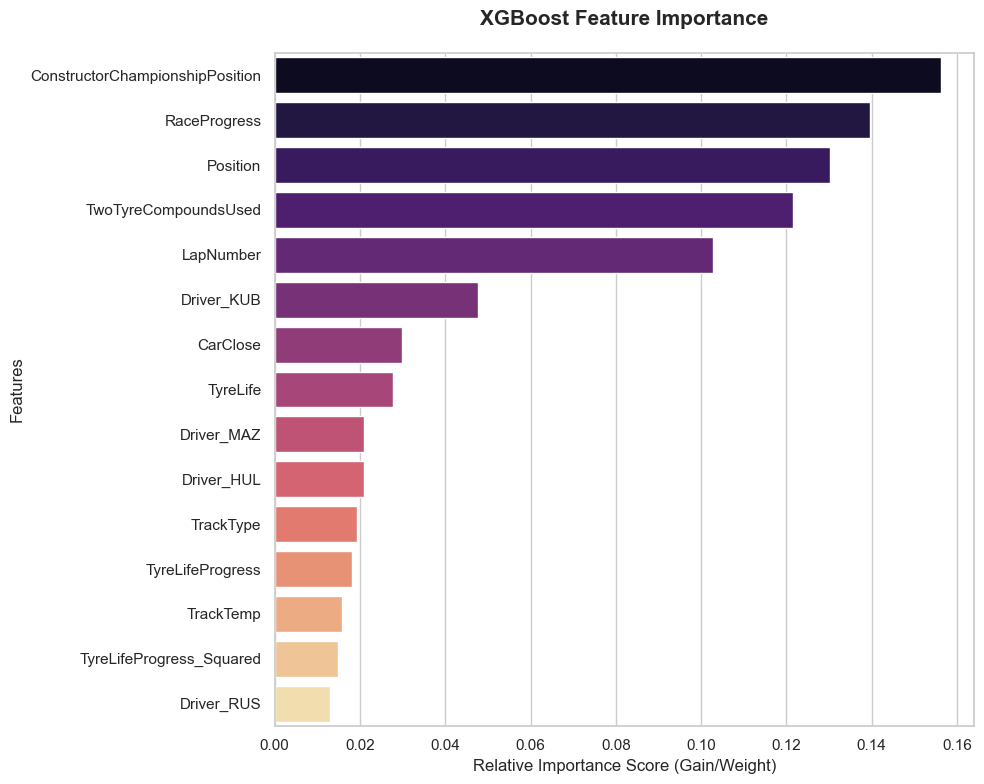


Top 5 Features for XGBoost Feature Importance:
                        Feature  Importance
ConstructorChampionshipPosition    0.156171
                   RaceProgress    0.139658
                       Position    0.130232
           TwoTyreCompoundsUsed    0.121623
                      LapNumber    0.102832


In [55]:
importance_df = plot_xgb_feature_importance(random_search.best_estimator_, X_train_xgb.columns)

In [56]:
import joblib

# ---------------------------------------------------------
# 1. SAVE THE OPTIMIZED XGBOOST MODEL
# ---------------------------------------------------------
# We save the model found by RandomizedSearch
xgb_filename = 'f1_pace_model_v3_optimized.joblib'

try:
    joblib.dump(best_xgb_model, xgb_filename)
    print(f"✅ XGBoost model successfully saved as '{xgb_filename}'")
except Exception as e:
    print(f"❌ Error saving the model: {e}")

# ---------------------------------------------------------
# 2. VERIFY THE SAVE (Optional)
# ---------------------------------------------------------
# Let's try to reload it to ensure integrity
loaded_model = joblib.load(xgb_filename)
print("🔍 Integrity check: Model reloaded successfully.")

# Quick test prediction to compare with the original
test_pred_original = best_xgb_model.predict(X_test_xgb.head(1))
test_pred_loaded = loaded_model.predict(X_test_xgb.head(1))

if np.isclose(test_pred_original, test_pred_loaded):
    print("💎 Validation passed: Predictions match perfectly!")

✅ XGBoost model successfully saved as 'f1_pace_model_v3_optimized.joblib'
🔍 Integrity check: Model reloaded successfully.
💎 Validation passed: Predictions match perfectly!


### PLOT

🏁 Evaluating the Optimized Model on the Test Set...
Tuned MAE:  0.713 seconds
Tuned RMSE: 0.960 seconds


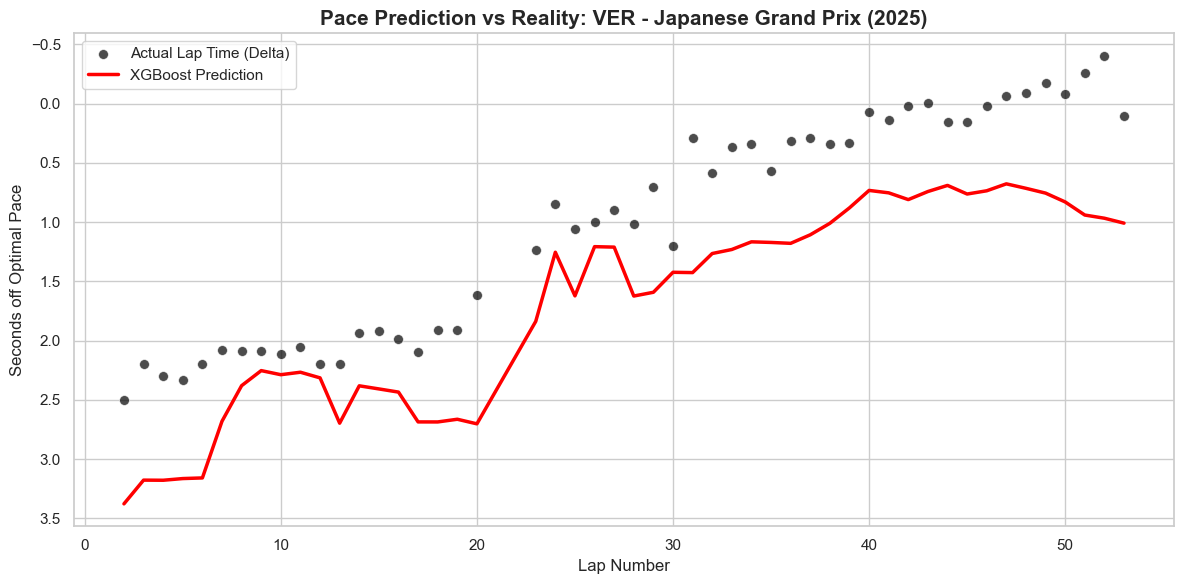

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set Seaborn theme
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. EVALUATE THE BEST MODEL ON UNSEEN TEST DATA
# ---------------------------------------------------------
print("🏁 Evaluating the Optimized Model on the Test Set...")

# random_search.best_estimator_ is already trained and ready!
y_pred_tuned = best_xgb_model.predict(X_test_xgb)

mae_tuned = mean_absolute_error(y_test_xgb, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_xgb, y_pred_tuned))

print(f"Tuned MAE:  {mae_tuned:.3f} seconds")
print(f"Tuned RMSE: {rmse_tuned:.3f} seconds")

# ---------------------------------------------------------
# 2. VISUALIZE PREDICTIONS VS REALITY (TELEMETRY STYLE)
# ---------------------------------------------------------
# Attach predictions back to our test dataframe
df_test_plot = df_test_xgb.copy()
df_test_plot['Predicted_LapDelta'] = y_pred_tuned

# Choose a random GP and Driver from the test set to visualize
sample_gp = df_test_plot['GP'].iloc[0]
target_driver = 'VER' # Change this to your preferred driver!

# Filter data
df_plot = df_test_plot[(df_test_plot['GP'] == sample_gp) & (df_test_plot['Driver_VER'] == 1)]

# If you used Label Encoding or if Driver_VER doesn't exist, use this fallback:
if df_plot.empty:
    # Try finding the first available driver in this GP
    first_driver_col = [col for col in df_test_plot.columns if col.startswith('Driver_') and df_test_plot[df_test_plot['GP'] == sample_gp][col].sum() > 0][0]
    df_plot = df_test_plot[(df_test_plot['GP'] == sample_gp) & (df_test_plot[first_driver_col] == 1)]
    target_driver = first_driver_col.replace('Driver_', '')

if not df_plot.empty:
    plt.figure(figsize=(12, 6))

    # Plot Actual Lap Delta (Scatter points for reality)
    sns.scatterplot(
        data=df_plot, 
        x='LapNumber', 
        y='LapDeltaSeconds', 
        color='black', 
        label='Actual Lap Time (Delta)',
        s=50,
        alpha=0.7
    )

    # Plot Predicted Lap Delta (Smooth line for the AI's "physics engine")
    sns.lineplot(
        data=df_plot, 
        x='LapNumber', 
        y='Predicted_LapDelta', 
        color='red', 
        linewidth=2.5,
        label='XGBoost Prediction'
    )

    # Formatting
    current_year = df_plot['Year'].iloc[0]
    plt.title(f"Pace Prediction vs Reality: {target_driver} - {sample_gp} ({current_year})", fontsize=15, fontweight='bold')
    plt.xlabel("Lap Number", fontsize=12)
    plt.ylabel("Seconds off Optimal Pace", fontsize=12)
    plt.legend(loc='upper left')
    
    # Invert Y axis so "faster" laps (lower delta) are higher up, like in real F1 telemetry
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find data for {target_driver} in {sample_gp}.")

# SIMULATION

In [ ]:
import pandas as pd
import numpy as np

def simulate_stint(driver_name, track_type, track_temp, start_lap, total_laps, compound='MEDIUM'):
    """
    Simulates a race stint using the XGBoost 'Pace Engine' and Neural Network 'Strategy Brain'.
    """
    results = []
    
    # Initialize state
    current_tyre_life = 0
    max_tyre_life_estimate = 40 # Standard reference for progress calculation
    
    # ---------------------------------------------------------
    # 1. PREPARE STATIC FEATURES (Driver One-Hot, etc.)
    # ---------------------------------------------------------
    # Create a template row with all features set to 0
    feature_columns = X_train.columns
    state_df = pd.DataFrame(0, index=[0], columns=feature_columns)
    
    # Set static features
    if f'Driver_{driver_name}' in state_df.columns:
        state_df[f'Driver_{driver_name}'] = 1
    if f'Compound_{compound}' in state_df.columns:
        state_df[f'Compound_{compound}'] = 1
        
    state_df['TrackType'] = track_type
    state_df['TrackTemp'] = track_temp
    # Assuming a mid-grid position for simulation
    state_df['Position'] = 0.5 
    state_df['ConstructorChampionshipPosition'] = 0.5

    print(f"--- Simulation Start: {driver_name} on {compound} tyres ---")

    # ---------------------------------------------------------
    # 2. STEP-BY-STEP SIMULATION LOOP
    # ---------------------------------------------------------
    for lap in range(start_lap, total_laps + 1):
        # Update dynamic features
        race_progress = lap / total_laps
        tyre_progress = current_tyre_life / max_tyre_life_estimate
        
        state_df['RaceProgress'] = race_progress
        state_df['TyreLifeProgress'] = tyre_progress
        state_df['TyreLifeProgress_Squared'] = tyre_progress ** 2
        state_df['LapNumber'] = lap
        
        # A) Predict Pace using XGBoost (Optimized Model)
        pace_delta = best_xgb_model.predict(state_df)[0]
        
        # B) Predict Pit Probability using Neural Network
        # We need to ensure the columns match the NN input exactly
        nn_input = state_df[X_train_nn.columns] # Using the NN feature list
        pit_prob = model.predict(nn_input, verbose=0)[0][0]
        
        results.append({
            'Lap': lap,
            'TyreLife': current_tyre_life,
            'PaceDelta': pace_delta,
            'PitProbability': pit_prob
        })
        
        # Check for Pit Stop decision (Threshold e.g. 0.6)
        if pit_prob > 0.6:
            print(f"🛑 PIT STOP SUGGESTED at Lap {lap} (Prob: {pit_prob:.2f})")
            break
            
        current_tyre_life += 1

    return pd.DataFrame(results)

# ---------------------------------------------------------
# TRY IT OUT!
# ---------------------------------------------------------
# Example: Verstappen at a High-Stress track (Type 1), 30°C
stint_data = simulate_stint('VER', track_type=1.0, track_temp=30.0, start_lap=1, total_laps=60)
display(stint_data)

In [58]:
print("df_test_nn:", df_test_nn.columns.tolist())
print("\ndf_test_xgb:", df_test_xgb.columns.tolist())

df_test_nn: ['Driver', 'LapNumber', 'Team', 'Position', 'InPits', 'TrackTemp', 'Year', 'GP', 'RaceProgress', 'TyreLifeProgress', 'CarClose', 'PitStopBehind', 'TwoTyreCompoundsUsed', 'TrackType', 'ConstructorChampionshipPosition', 'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT', 'CleanTrackStatus_GreenFlag', 'CleanTrackStatus_RedFlag', 'CleanTrackStatus_SafetyCar', 'CleanTrackStatus_VSC', 'CleanTrackStatus_YellowFlag']

df_test_xgb: ['LapTime', 'LapNumber', 'TyreLife', 'Team', 'TrackStatus', 'Position', 'LapTime_ms', 'InPits', 'TrackTemp', 'Year', 'GP', 'RaceProgress', 'TyreLifeProgress', 'CarClose', 'PitStopBehind', 'TwoTyreCompoundsUsed', 'TrackType', 'ConstructorChampionshipPosition', 'LapDeltaSeconds', 'TyreLifeProgress_Squared', 'Driver_ALB', 'Driver_ALO', 'Driver_ANT', 'Driver_BEA', 'Driver_BOR', 'Driver_BOT', 'Driver_COL', 'Driver_DEV', 'Driver_DOO', 'Driver_FIT', 'Driver_GAS', 'Driver_GIO', 'Driver_GRO', 'Driver_HAD', 'Driver_HAM', 'Driver_HUL', 'Driver_KUB', 'Driver_KVY', '

In [59]:
print("NN expects these columns:", X_train_nn.columns.tolist())
print("\nXGB dataset has these columns:", X_test_xgb.columns.tolist())

NN expects these columns: ['Position', 'TrackTemp', 'RaceProgress', 'TyreLifeProgress', 'CarClose', 'PitStopBehind', 'TwoTyreCompoundsUsed', 'TrackType', 'ConstructorChampionshipPosition', 'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT', 'CleanTrackStatus_GreenFlag', 'CleanTrackStatus_RedFlag', 'CleanTrackStatus_SafetyCar', 'CleanTrackStatus_VSC', 'CleanTrackStatus_YellowFlag']

XGB dataset has these columns: ['LapNumber', 'TyreLife', 'Position', 'TrackTemp', 'RaceProgress', 'TyreLifeProgress', 'CarClose', 'PitStopBehind', 'TwoTyreCompoundsUsed', 'TrackType', 'ConstructorChampionshipPosition', 'TyreLifeProgress_Squared', 'Driver_ALB', 'Driver_ALO', 'Driver_ANT', 'Driver_BEA', 'Driver_BOR', 'Driver_BOT', 'Driver_COL', 'Driver_DEV', 'Driver_DOO', 'Driver_FIT', 'Driver_GAS', 'Driver_GIO', 'Driver_GRO', 'Driver_HAD', 'Driver_HAM', 'Driver_HUL', 'Driver_KUB', 'Driver_KVY', 'Driver_LAT', 'Driver_LAW', 'Driver_LEC', 'Driver_MAG', 'Driver_MAZ', 'Driver_MSC', 'Driver_NOR', 'Driver_OCO', 'Dr

In [162]:
def run_backtesting_challenge(gp_name, driver_code, year=2025):
    driver_col = f'Driver_{driver_code}'
    
    # Use the XGBoost test dataframe as the primary source of truth
    race_data = df_test_xgb[(df_test_xgb['GP'] == gp_name) & 
                            (df_test_xgb[driver_col] == 1) & 
                            (df_test_xgb['Year'] == year)].sort_values('LapNumber')
    
    if race_data.empty:
        print(f"❌ No data found for {driver_code} at {gp_name} {year}")
        return

    sim_results = []
    current_tyre_life = 0
    
    print(f"--- 🏁 AI STRATEGY CHALLENGE: {driver_code} @ {gp_name} ---")

    for i, (index, real_lap) in enumerate(race_data.iterrows()):
        # Current features from the XGBoost test set
        current_features = X_test_xgb.loc[[index]].copy()
        
        # Override simulated TyreLife
        current_tyre_life_norm = current_tyre_life / 40.0
        current_features['TyreLifeProgress'] = current_tyre_life_norm
        current_features['TyreLifeProgress_Squared'] = current_tyre_life_norm ** 2
        
        # --- A) PACING (XGBoost) ---
        predicted_delta = best_xgb_model.predict(current_features)[0]
        
        # --- B) STRATEGY (Neural Network) ---
        # FIX: If the NN expects 'CleanTrackStatus' but XGB has 'TrackStatus', rename here:
        # We create a specific copy for the NN to avoid messing with XGBoost
        nn_input_df = current_features.copy()
        
        # Example of dynamic renaming (adjust based on your print output above)
        nn_input_df.columns = [col.replace('TrackStatus_', 'CleanTrackStatus_') for col in nn_input_df.columns]
        
        # Select only the columns the NN was trained on
        try:
            nn_input = nn_input_df[X_train_nn.columns]
            pit_prob = model.predict(nn_input, verbose=0)[0][0]
        except KeyError as e:
            print(f"⚠️ Still a KeyError! Missing: {e}")
            break
        
        sim_results.append({
            'Lap': real_lap['LapNumber'],
            'Real_InPits': real_lap['InPits'],
            'AI_Pit_Prob': pit_prob,
            'AI_Pace_Delta': predicted_delta
        })
        
        # --- C) DECISION MAKING ---
        if pit_prob > 0.55:
            print(f"📢 Lap {int(real_lap['LapNumber'])}: AI calls BOX! (Prob: {pit_prob:.2f} | Pace Delta: {predicted_delta:.2f}s)")
            current_tyre_life = 0 
        else:
            current_tyre_life += 1

    # Final Summary
    sim_df = pd.DataFrame(sim_results)
    return sim_df


challenge_results = run_backtesting_challenge('Japanese Grand Prix', 'VER')

--- 🏁 AI STRATEGY CHALLENGE: VER @ Japanese Grand Prix ---
⚠️ Still a KeyError! Missing: "['CleanTrackStatus_GreenFlag', 'CleanTrackStatus_RedFlag', 'CleanTrackStatus_SafetyCar', 'CleanTrackStatus_VSC', 'CleanTrackStatus_YellowFlag'] not in index"


In [60]:
# Create the definitive merged dataset
# We take df_test_nn as base and attach all missing XGBoost columns
df_test_final = pd.merge(
    df_test_nn, 
    df_test_xgb[['Year', 'GP', 'LapNumber', 'TyreLife', 'TyreLifeProgress_Squared'] + 
                [col for col in df_test_xgb.columns if col.startswith('Driver_')]], 
    on=['Year', 'GP', 'LapNumber'], 
    how='left'
)

# Fill gaps for driver columns (they are constant for a single race)
driver_cols = [col for col in df_test_final.columns if col.startswith('Driver_')]
df_test_final[driver_cols] = df_test_final.groupby(['Year', 'GP'])[driver_cols].ffill().bfill()

print(f"Super-dataset ready! Columns available: {df_test_final.shape[1]}")

Super-dataset ready! Columns available: 63


In [69]:
check_dataset_integrity(df_test_final)

--- Dataset Integrity Check ---
⚠️ Missing values detected:
                          Total Nulls  Percentage
TyreLife                         1362    0.471386
TyreLifeProgress_Squared         1362    0.471386


,Total Nulls,Percentage
TyreLife,1362,0.471386
TyreLifeProgress_Squared,1362,0.471386


In [62]:
model = tf.keras.models.load_model('f1_strategic_model_m10.keras')

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_backtesting_challenge(gp_name, driver_code, year=2025):
    driver_col = f'Driver_{driver_code}'
    
    # Filter the final dataset
    race_data = df_test_final[(df_test_final['GP'] == gp_name) & 
                              (df_test_final['Driver'] == driver_code) & 
                              (df_test_final['Year'] == year)].sort_values('LapNumber')
    
    if race_data.empty:
        print(f"❌ No data found for {driver_code} in {gp_name} {year}")
        return

    sim_results = []
    current_tyre_life = 0
    
    # Use the saved feature lists to slice the data correctly for each model
    xgb_features = X_train_xgb.columns
    nn_features = X_train_nn.columns

    print(f"--- 🏁 AI STRATEGY CHALLENGE: {driver_code} @ {gp_name} ---")

    for i, (index, real_lap) in enumerate(race_data.iterrows()):
        current_lap_features = race_data.loc[[index]].copy()
        
        # Update simulation-specific features
        norm_life = current_tyre_life / 40.0
        current_lap_features['TyreLifeProgress'] = norm_life
        current_lap_features['TyreLifeProgress_Squared'] = norm_life ** 2
        
        # --- A) PACING (XGBoost) ---
        # Note: XGBoost might see a Safety Car lap. 
        # It will predict a high delta, which is realistic!
        xgb_input = current_lap_features[xgb_features]
        predicted_delta = best_xgb_model.predict(xgb_input)[0]
        
        # --- B) STRATEGY (Neural Network) ---
        nn_input = current_lap_features[nn_features]
        pit_prob = model.predict(nn_input, verbose=0)[0][0]
        
        sim_results.append({
            'Lap': int(real_lap['LapNumber']),
            'Real_InPits': real_lap['InPits'],
            'AI_Pit_Prob': pit_prob,
            'AI_Pace_Delta': predicted_delta,
            'TrackStatus': real_lap.get('TrackStatus', 1.0)
        })
        
        # C) DECISION MAKING (Refined Logic)
        # We only pit if probability is very high AND we have completed at least 10 laps
        if pit_prob > 0.85 and current_tyre_life > 10:
            print(f"📢 Lap {int(real_lap['LapNumber'])}: STRATEGIC BOX! (Prob: {pit_prob:.2f} | Pace Delta: {predicted_delta:.2f}s)")
            current_tyre_life = 0 
        elif real_lap['CleanTrackStatus_SafetyCar'] == 1 and pit_prob > 0.40:
             print(f"📢 Lap {int(real_lap['LapNumber'])}: SAFETY CAR BOX! (Prob: {pit_prob:.2f})")
             current_tyre_life = 0
        else:
            current_tyre_life += 1

    return pd.DataFrame(sim_results)

# ---------------------------------------------------------
# EXECUTE THE CHALLENGE
# ---------------------------------------------------------
# Example: Let's see if the AI matches Verstappen's strategy in Japan
challenge_results = run_backtesting_challenge('Japanese Grand Prix', 'VER')

--- 🏁 AI STRATEGY CHALLENGE: VER @ Japanese Grand Prix ---
📢 Lap 3: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 3.54s)
📢 Lap 5: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 3.54s)
📢 Lap 7: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 3.60s)
📢 Lap 9: STRATEGIC BOX! (Prob: 0.86 | Pace Delta: 3.20s)
📢 Lap 11: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 3.22s)
📢 Lap 13: STRATEGIC BOX! (Prob: 0.86 | Pace Delta: 3.36s)
📢 Lap 15: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 3.16s)
📢 Lap 17: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 3.29s)
📢 Lap 19: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 3.19s)
📢 Lap 22: STRATEGIC BOX! (Prob: 0.86 | Pace Delta: 2.81s)
📢 Lap 26: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 1.99s)
📢 Lap 29: STRATEGIC BOX! (Prob: 0.86 | Pace Delta: 2.19s)
📢 Lap 32: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 2.22s)
📢 Lap 35: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 1.84s)
📢 Lap 38: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 1.60s)
📢 Lap 41: STRATEGIC BOX! (Prob: 0.85 | Pace Delta: 1.21s)
📢 Lap 44: STRATEG

In [ ]:
def run_backtesting_challenge(gp_name, driver_code, year=2025):
    driver_col = f'Driver_{driver_code}'
    race_data = df_test_final[(df_test_final['GP'] == gp_name) & 
                              (df_test_final['Driver'] == driver_code) & 
                              (df_test_final['Year'] == year)].sort_values('LapNumber')
    
    if race_data.empty:
        print(f"❌ Nessun dato trovato per {driver_code} in {gp_name} {year}")
        return

    sim_results = []
    current_tyre_life = 0 
    last_pit_lap = 0
    min_stint_length = 12 # Filtro Anti-Panico: minimo 12 giri
    
    xgb_features = X_train_xgb.columns.tolist() # Usa le nuove colonne pulite
    nn_features = X_train_nn.columns.tolist()

    print(f"--- 🏁 AI STRATEGY CHALLENGE: {driver_code} @ {gp_name} ---")

    for i, (index, real_lap) in enumerate(race_data.iterrows()):
        current_lap_features = race_data.loc[[index]].copy()
        
        # Simula il progresso della gomma
        norm_life = current_tyre_life / 40.0
        current_lap_features['TyreLife'] = current_tyre_life
        current_lap_features['TyreLifeProgress'] = norm_life
        current_lap_features['TyreLifeProgress_Squared'] = norm_life ** 2
        
        # A) PACING (XGBoost)
        xgb_input = current_lap_features[xgb_features]
        predicted_delta = best_xgb_model.predict(xgb_input)[0]
        
        # B) STRATEGY (Neural Network)
        nn_input = current_lap_features[nn_features]
        pit_prob = model.predict(nn_input, verbose=0)[0][0]
        
        sim_results.append({
            'Lap': int(real_lap['LapNumber']),
            'Real_InPits': real_lap['InPits'],
            'AI_Pit_Prob': pit_prob,
            'AI_Pace_Delta': predicted_delta
        })
        
        # C) DECISION LOGIC
        laps_since_pit = real_lap['LapNumber'] - last_pit_lap
        
        # BOX STRATEGICO: Probabilità > 85% E Stint minimo superato
        if pit_prob > 0.85 and laps_since_pit >= min_stint_length:
            print(f"📢 Lap {int(real_lap['LapNumber'])}: STRATEGIC BOX! (Prob: {pit_prob:.2f} | Pace Delta: {predicted_delta:.2f}s)")
            current_tyre_life = 0 
            last_pit_lap = real_lap['LapNumber']
            
        # BOX SAFETY CAR: Probabilità > 45% E Stint minimo di 5 giri
        elif real_lap.get('CleanTrackStatus_SafetyCar', 0) == 1 and pit_prob > 0.45 and laps_since_pit > 5:
            print(f"📢 Lap {int(real_lap['LapNumber'])}: SAFETY CAR BOX! (Prob: {pit_prob:.2f})")
            current_tyre_life = 0
            last_pit_lap = real_lap['LapNumber']
            
        else:
            current_tyre_life += 1

    return pd.DataFrame(sim_results)

# Lancia la sfida!
challenge_results = run_backtesting_challenge('Japanese Grand Prix', 'VER')

In [72]:
import pandas as pd
import numpy as np

def run_diagnostic_loop(race_data, xgb_features, nn_features, xgb_model, nn_model, max_laps=15):
    """
    Diagnostic function to isolate model predictions lap-by-lap without applying any strategy logic.
    This helps us see exactly what the models 'think' given a controlled tyre age.
    """
    print("--- 🔍 START DIAGNOSTIC LOOP ---")
    
    # Initialize our simulated tyre age counter
    simulated_tyre_life = 0
    
    # Iterate through the actual race data row by row
    for index, real_lap in race_data.iterrows():
        lap_number = int(real_lap['LapNumber'])
        
        # 1. Create a copy of the current lap to inject our simulated variables
        current_state = real_lap.copy()
        
        # 2. Inject simulated tyre data (overriding historical data)
        current_state['TyreLife'] = simulated_tyre_life
        
        # Calculate normalized progress based on a standard 40-lap stint
        norm_life = simulated_tyre_life / 40.0
        current_state['TyreLifeProgress'] = norm_life
        current_state['TyreLifeProgress_Squared'] = norm_life ** 2
        
        # Convert the Series to a 1-row DataFrame for model prediction
        current_state_df = pd.DataFrame([current_state])
        
        # 3. XGBoost: Predict Pace Delta
        try:
            xgb_input = current_state_df[xgb_features]
            predicted_delta = xgb_model.predict(xgb_input)[0]
        except Exception as e:
            print(f"❌ XGBoost Error at lap {lap_number}: {e}")
            break
            
        # 4. Neural Network: Predict Pit Stop Probability
        try:
            nn_input = current_state_df[nn_features]
            pit_prob = nn_model.predict(nn_input, verbose=0)[0][0]
        except Exception as e:
            print(f"❌ NN Error at lap {lap_number}: {e}")
            break
            
        # 5. Print out the 'brain' of the models for this exact lap
        fuel_prog = current_state['RaceProgress']
        
        # Display the output cleanly to diagnose weird model behaviors
        print(f"Lap {lap_number:02d} | TyreAge: {simulated_tyre_life:02d} | FuelProg: {fuel_prog:.2f} || "
              f"PaceDelta: {predicted_delta:+.2f}s | PitProb: {pit_prob:.3f}")
        
        # 6. Advance the simulated tyre age for the next lap
        simulated_tyre_life += 1
        
        # Stop early to keep the output readable
        if simulated_tyre_life >= max_laps:
            break

    print("--- 🛑 END DIAGNOSTIC LOOP ---")


In [73]:
# Scegliamo un pilota e una gara dal tuo dataset di test che contiene tutte le features
test_df = df_test_final[(df_test_final['GP'] == 'Japanese Grand Prix') & 
                        (df_test_final['Driver'] == 'VER')].sort_values('LapNumber')

xgb_features = X_train_xgb.columns
nn_features = X_train_nn.columns

# Lanciamo la diagnosi
run_diagnostic_loop(test_df, xgb_features, nn_features, best_xgb_model, model)

--- 🔍 START DIAGNOSTIC LOOP ---
Lap 01 | TyreAge: 00 | FuelProg: 0.02 || PaceDelta: +4.87s | PitProb: 0.008
Lap 02 | TyreAge: 01 | FuelProg: 0.04 || PaceDelta: +4.95s | PitProb: 0.011
Lap 02 | TyreAge: 02 | FuelProg: 0.04 || PaceDelta: +3.40s | PitProb: 0.015
Lap 02 | TyreAge: 03 | FuelProg: 0.04 || PaceDelta: +3.37s | PitProb: 0.020
Lap 02 | TyreAge: 04 | FuelProg: 0.04 || PaceDelta: +3.38s | PitProb: 0.027
Lap 02 | TyreAge: 05 | FuelProg: 0.04 || PaceDelta: +3.38s | PitProb: 0.035
Lap 02 | TyreAge: 06 | FuelProg: 0.04 || PaceDelta: +3.38s | PitProb: 0.046
Lap 02 | TyreAge: 07 | FuelProg: 0.04 || PaceDelta: +3.40s | PitProb: 0.060
Lap 02 | TyreAge: 08 | FuelProg: 0.04 || PaceDelta: +3.40s | PitProb: 0.077
Lap 02 | TyreAge: 09 | FuelProg: 0.04 || PaceDelta: +3.23s | PitProb: 0.099
Lap 02 | TyreAge: 10 | FuelProg: 0.04 || PaceDelta: +3.42s | PitProb: 0.125
Lap 02 | TyreAge: 11 | FuelProg: 0.04 || PaceDelta: +3.43s | PitProb: 0.155
Lap 02 | TyreAge: 12 | FuelProg: 0.04 || PaceDelta: +3.4